Célula 1: instalar e importar bibliotecas

In [1]:
!pip install openpyxl xlrd -q

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

Célula 2: upload ou leitura dos arquivos

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Base Vendas - 2022.xlsx to Base Vendas - 2022.xlsx
Saving Cadastro Produtos.xlsx to Cadastro Produtos.xlsx


In [6]:
produtos = pd.read_excel("Cadastro Produtos.xlsx")
vendas = pd.read_excel("Base Vendas - 2022.xlsx")

In [5]:
produtos = pd.read_csv("Cadastro Produtos.csv")
vendas = pd.read_csv("Base Vendas - 2022.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'Cadastro Produtos.csv'

Célula 3: inspeção inicial

In [7]:
print("Produtos:", produtos.shape)
print("Vendas:", vendas.shape)

display(produtos.head())
display(vendas.head())

display(produtos.info())
display(vendas.info())

Produtos: (293, 7)
Vendas: (29481, 6)


,SKU,Produto,Marca,Tipo do Produto,Preço Unitario,Custo Unitario,Observação
0,HL1,M510 Mouse sem fio - Vermelho,Logitech,Mouse,25.95,6.50,NaN
1,HL2,Mouse sem fio M170 - Preto,Logitech,Mouse,19.95,5.00,NaN
2,HL3,"Camisa Hashtag Eletro Masculina, P - Branco",Hashtag,Camisa,25.00,11.00,NaN
3,HL4,"Camisa Hashtag Eletro Masculina, M - Branco",Hashtag,Camisa,25.00,11.00,Conferir estoque
4,HL5,Mouse sem fio D09 - Azul,Multilaser,Mouse,11.99,3.40,NaN


,Data da Venda,Ordem de Compra,SKU,ID Cliente,Qtd Vendida,ID Loja
0,2022-01-01,SO61285,HL216,23791,2,166
1,2022-01-01,SO61285,HL1,23791,1,93
2,2022-01-01,SO61285,HL227,23791,1,94
3,2022-01-01,SO61301,HL216,16747,2,17
4,2022-01-01,SO61301,HL89,16747,1,115


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 293 entries, 0 to 292
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   SKU              293 non-null    object 
 1   Produto          293 non-null    object 
 2   Marca            293 non-null    object 
 3   Tipo do Produto  293 non-null    object 
 4   Preço Unitario   293 non-null    float64
 5   Custo Unitario   293 non-null    float64
 6   Observação       2 non-null      object 
dtypes: float64(2), object(5)
memory usage: 16.2+ KB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29481 entries, 0 to 29480
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Data da Venda    29481 non-null  datetime64[ns]
 1   Ordem de Compra  29481 non-null  object        
 2   SKU              29481 non-null  object        
 3   ID Cliente       29481 non-null  int64         
 4   Qtd Vendida      29481 non-null  int64         
 5   ID Loja          29481 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(2)
memory usage: 1.3+ MB


None

In [8]:
nulos_produtos = (produtos.isnull().mean() * 100).sort_values(ascending=False)
nulos_vendas = (vendas.isnull().mean() * 100).sort_values(ascending=False)

display(nulos_produtos)
display(nulos_vendas)

,0
Observação,99.32
Produto,0.00
SKU,0.00
Marca,0.00
Tipo do Produto,0.00
Preço Unitario,0.00
Custo Unitario,0.00


,0
Data da Venda,0.00
Ordem de Compra,0.00
SKU,0.00
ID Cliente,0.00
Qtd Vendida,0.00
ID Loja,0.00


Célula 4: padronizar nomes das colunas

In [9]:
import unicodedata

def normalizar_colunas(df):
    cols = []
    for col in df.columns:
        col = str(col).strip().lower()
        col = unicodedata.normalize("NFKD", col).encode("ascii", "ignore").decode("utf-8")
        col = col.replace(" ", "_").replace("-", "_").replace("/", "_")
        cols.append(col)
    df.columns = cols
    return df

produtos = normalizar_colunas(produtos)
vendas = normalizar_colunas(vendas)

print(produtos.columns.tolist())
print(vendas.columns.tolist())

['sku', 'produto', 'marca', 'tipo_do_produto', 'preco_unitario', 'custo_unitario', 'observacao']
['data_da_venda', 'ordem_de_compra', 'sku', 'id_cliente', 'qtd_vendida', 'id_loja']


Célula 5: renomear colunas principais

In [127]:
produtos = produtos.rename(columns={
    "produto": "nome_produto"
})

# Ensure 'categoria' exists in produtos, using 'tipo_do_produto' as a proxy if it's not there
if "categoria" not in produtos.columns and "tipo_do_produto" in produtos.columns:
    produtos["categoria"] = produtos["tipo_do_produto"]

# Renomear 'data_da_venda' para 'data_venda'
if 'data_da_venda' in vendas.columns and 'data_venda' not in vendas.columns:
    vendas = vendas.rename(columns={'data_da_venda': 'data_venda'})

# Renomear 'qtd_vendida' para 'quantidade'
if 'qtd_vendida' in vendas.columns and 'quantidade' not in vendas.columns:
    vendas = vendas.rename(columns={'qtd_vendida': 'quantidade'})

In [128]:
colunas_produtos_esperadas = ["sku", "nome_produto"]
colunas_vendas_esperadas = ["data_venda", "sku", "quantidade"]

for col in colunas_produtos_esperadas:
    if col not in produtos.columns:
        print(f"Coluna ausente em produtos: {col}")

for col in colunas_vendas_esperadas:
    if col not in vendas.columns:
        print(f"Coluna ausente em vendas: {col}")

Célula 6: limpar campos de texto e SKU

In [129]:
def limpar_texto(s):
    if pd.isna(s):
        return np.nan
    return str(s).strip().upper()

produtos["sku"] = produtos["sku"].apply(limpar_texto)
vendas["sku"] = vendas["sku"].apply(limpar_texto)

if "nome_produto" in produtos.columns:
    produtos["nome_produto"] = produtos["nome_produto"].astype(str).str.strip()

if "categoria" in produtos.columns:
    produtos["categoria"] = produtos["categoria"].astype(str).str.strip().str.title()

Célula 7: tratar datas

In [130]:
if 'data_da_venda' in vendas.columns and 'data_venda' not in vendas.columns:
    vendas = vendas.rename(columns={'data_da_venda': 'data_venda'})
vendas["data_venda"] = pd.to_datetime(vendas["data_venda"], errors="coerce", dayfirst=True)

In [131]:
datas_invalidas = vendas["data_venda"].isna().sum()
print("Datas inválidas:", datas_invalidas)

Datas inválidas: 0


In [132]:
vendas = vendas.dropna(subset=["data_venda"]).copy()

Célula 8: tratar colunas numéricas

In [133]:
colunas_numericas = ["quantidade", "valor_unitario", "valor_total"]

for col in colunas_numericas:
    if col in vendas.columns:
        vendas[col] = (
            vendas[col]
            .astype(str)
            .str.replace(".", "", regex=False)
            .str.replace(",", ".", regex=False)
        )
        vendas[col] = pd.to_numeric(vendas[col], errors="coerce")

In [56]:
if "valor_total" not in vendas.columns and {"quantidade", "valor_unitario"}.issubset(vendas.columns):
    vendas["valor_total"] = vendas["quantidade"] * vendas["valor_unitario"]

In [135]:
if "quantidade" in vendas.columns:
    vendas = vendas[vendas["quantidade"] > 0]

if "valor_total" in vendas.columns:
    vendas = vendas[vendas["valor_total"] >= 0]

Célula 9: remover duplicados e nulos críticos

In [136]:
print("Duplicados em produtos:", produtos.duplicated().sum())
print("Duplicados em vendas:", vendas.duplicated().sum())

produtos = produtos.drop_duplicates().copy()
vendas = vendas.drop_duplicates().copy()

Duplicados em produtos: 0
Duplicados em vendas: 0


In [137]:
produtos = produtos.dropna(subset=["sku"]).copy()
vendas = vendas.dropna(subset=["sku", "data_venda", "quantidade"]).copy()

In [138]:
sku_repetido = produtos["sku"].duplicated().sum()
print("SKUs duplicados no cadastro:", sku_repetido)

SKUs duplicados no cadastro: 0


Célula 10: integrar vendas com produtos

In [139]:
base = vendas.merge(
    produtos,
    on="sku",
    how="left",
    indicator=True
)

In [140]:
base["_merge"].value_counts(dropna=False)

,count
_merge,
both,29481
left_only,0
right_only,0


In [141]:
sem_cadastro = base[base["_merge"] == "left_only"]
print("Vendas sem cadastro de produto:", sem_cadastro.shape[0])
display(sem_cadastro.head())

Vendas sem cadastro de produto: 0


,data_venda,ordem_de_compra,sku,id_cliente,quantidade,id_loja,nome_produto,marca,tipo_do_produto,preco_unitario,custo_unitario,observacao,categoria,_merge


In [142]:
base = base.drop(columns=["_merge"])

Célula 11: criar variáveis derivadas

In [143]:
base["ano"] = base["data_venda"].dt.year
base["mes"] = base["data_venda"].dt.month
base["nome_mes"] = base["data_venda"].dt.month_name()
base["dia"] = base["data_venda"].dt.day
base["dia_semana"] = base["data_venda"].dt.day_name()
base["fim_de_semana"] = base["data_venda"].dt.weekday >= 5
base["ano_mes"] = base["data_venda"].dt.to_period("M").astype(str)
base["trimestre"] = base["data_venda"].dt.quarter

In [144]:
if "promocao" in base.columns:
    base["promocao_flag"] = base["promocao"].fillna("Nao").astype(str).str.lower().isin(
        ["sim", "s", "1", "true", "promo", "promocao"]
    ).astype(int)
else:
    base["promocao_flag"] = 0

Célula 12: criar base diária por produto

In [145]:
# Check if 'valor_total' exists before creating it
if 'valor_total' not in base.columns and 'quantidade' in base.columns and 'preco_unitario' in base.columns:
    base["valor_total"] = base["quantidade"] * base["preco_unitario"]

base_diaria_produto = (
    base.groupby(["data_venda", "sku"], as_index=False)
        .agg(
            quantidade_vendida=("quantidade", "sum"),
            receita=("valor_total", "sum")
        )
)

In [146]:
if "categoria" in base.columns:
    cat_por_sku = base[["sku", "categoria"]].drop_duplicates()
    base_diaria_produto = base_diaria_produto.merge(cat_por_sku, on="sku", how="left")

In [147]:
base_diaria_geral = (
    base.groupby("data_venda", as_index=False)
        .agg(
            quantidade_vendida=("quantidade", "sum"),
            receita=("valor_total", "sum")
        )
)

Célula 13: validação rápida

In [148]:
print("Período da base:", base["data_venda"].min(), "até", base["data_venda"].max())
print("Qtd SKUs únicos:", base["sku"].nunique())
print("Qtd produtos sem categoria:", base["categoria"].isna().sum() if "categoria" in base.columns else "coluna inexistente")
print("Quantidade total vendida:", base["quantidade"].sum())
print("Receita total:", base["valor_total"].sum() if "valor_total" in base.columns else "coluna inexistente")

Período da base: 2022-01-01 00:00:00 até 2022-06-30 00:00:00
Qtd SKUs únicos: 102
Qtd produtos sem categoria: 0
Quantidade total vendida: 45314
Receita total: 7059459.47


In [149]:
display(base.head())
display(base_diaria_produto.head())
display(base_diaria_geral.head())

,data_venda,ordem_de_compra,sku,id_cliente,quantidade,id_loja,nome_produto,marca,tipo_do_produto,preco_unitario,custo_unitario,observacao,categoria,ano,mes,nome_mes,dia,dia_semana,fim_de_semana,ano_mes,trimestre,promocao_flag,valor_total
0,2022-01-01,SO61285,HL216,23791,2,166,Teclado LG X130 - Branco,LG,Teclado,10.00,2.50,NaN,Teclado,2022,1,January,1,Saturday,True,2022-01,1,0,20.00
1,2022-01-01,SO61285,HL1,23791,1,93,M510 Mouse sem fio - Vermelho,Logitech,Mouse,25.95,6.50,NaN,Mouse,2022,1,January,1,Saturday,True,2022-01,1,0,25.95
2,2022-01-01,SO61285,HL227,23791,1,94,"Monitor LED 24"" wide Gamer 75Hz T350 - Preto",Samsung,Monitor,179.99,46.80,NaN,Monitor,2022,1,January,1,Saturday,True,2022-01,1,0,179.99
3,2022-01-01,SO61301,HL216,16747,2,17,Teclado LG X130 - Branco,LG,Teclado,10.00,2.50,NaN,Teclado,2022,1,January,1,Saturday,True,2022-01,1,0,20.00
4,2022-01-01,SO61301,HL89,16747,1,115,HP Pavilion 17.3' - Preto,HP,Notebook,799.00,199.80,NaN,Notebook,2022,1,January,1,Saturday,True,2022-01,1,0,799.00


,data_venda,sku,quantidade_vendida,receita,categoria
0,2022-01-01,HL1,4,103.80,Mouse
1,2022-01-01,HL158,1,48.90,Casaco
2,2022-01-01,HL162,1,45.90,Casaco
3,2022-01-01,HL164,25,124.75,Mouse
4,2022-01-01,HL165,10,39.90,Mouse


,data_venda,quantidade_vendida,receita
0,2022-01-01,155,"14,070.40"
1,2022-01-02,211,"30,829.34"
2,2022-01-03,220,"24,662.41"
3,2022-01-04,216,"45,046.04"
4,2022-01-05,212,"36,860.61"


Célula 14: salvar arquivos tratados

In [150]:
base.to_csv("base_analitica.csv", index=False)
vendas.to_csv("vendas_tratada.csv", index=False)
produtos.to_csv("produtos_tratado.csv", index=False)
base_diaria_produto.to_csv("base_diaria_produto.csv", index=False)
base_diaria_geral.to_csv("base_diaria_geral.csv", index=False)

In [151]:
from google.colab import files

files.download("base_analitica.csv")
files.download("base_diaria_produto.csv")
files.download("base_diaria_geral.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Resultado esperado dessa etapa
Ao final do Pipeline 1, você deve ter:
dados limpos e padronizados;
SKUs compatíveis entre cadastro e vendas;
datas convertidas corretamente; �
colunas numéricas consistentes;
base integrada pronta para análise;
tabelas diárias prontas para forecast.

A primeira etapa do projeto consistiu na ingestão, limpeza e padronização das bases de produtos e vendas no Google Colab com Python. Foram tratadas inconsistências de nomes de colunas, formatos de datas, tipos numéricos, valores ausentes, duplicidades e padronização de SKUs, permitindo a integração entre as tabelas e a construção de uma base analítica confiável para as etapas seguintes de análise exploratória e previsão de demanda.

PIPELINES 2
O Pipeline 2 no Colab é a etapa de análise exploratória e diagnóstico, onde você transforma a base tratada em respostas objetivas para o desafio: quais produtos vendem mais, quando as vendas aumentam ou caem, quais padrões sazonais existem e como promoções afetam a demanda. �
Essa etapa é importante porque a previsão de demanda não deve começar “no escuro”; primeiro é preciso entender o comportamento histórico da série, seus picos, vales, tendências e possíveis eventos explicativos. �
Objetivo do Pipeline 2
Ao final deste pipeline, você deve conseguir responder:
Quais são os produtos mais e menos vendidos. �
Quais dias e meses têm maior e menor volume de vendas. �
Se existe sazonalidade por mês, dia da semana ou período promocional. �
Se promoções alteram significativamente a quantidade vendida. �
Quais gráficos vão entrar no relatório e no dashboard. �
Além disso, você vai gerar tabelas-resumo e visualizações que depois poderão ser reaproveitadas no Streamlit e no Power BI. �
Arquivos que você deve usar
Neste pipeline, partimos dos arquivos do Pipeline 1:
base_analitica.csv
base_diaria_produto.csv
base_diaria_geral.csv
Se você ainda estiver na mesma sessão do Colab, pode continuar usando os DataFrames já carregados. Caso contrário:

In [152]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

base = pd.read_csv("base_analitica.csv", parse_dates=["data_venda"])
base_diaria_produto = pd.read_csv("base_diaria_produto.csv", parse_dates=["data_venda"])
base_diaria_geral = pd.read_csv("base_diaria_geral.csv", parse_dates=["data_venda"])

Bloco 1: visão geral dos dados

In [153]:
print("Linhas da base analítica:", base.shape[0])
print("Colunas da base analítica:", base.shape[1])
print("Período:", base["data_venda"].min(), "até", base["data_venda"].max())
print("Qtd de produtos únicos:", base["sku"].nunique())
print("Qtd total vendida:", base["quantidade"].sum())
print("Receita total:", base["valor_total"].sum() if "valor_total" in base.columns else "coluna não encontrada")

Linhas da base analítica: 29481
Colunas da base analítica: 23
Período: 2022-01-01 00:00:00 até 2022-06-30 00:00:00
Qtd de produtos únicos: 102
Qtd total vendida: 45314
Receita total: 7059459.47


In [154]:
display(base[["quantidade"]].describe())

if "valor_total" in base.columns:
    display(base[["valor_total"]].describe())

,quantidade
count,"29,481.00"
mean,1.54
std,0.62
min,1.00
25%,1.00
50%,1.00
75%,2.00
max,3.00


,valor_total
count,"29,481.00"
mean,239.46
std,697.32
min,3.99
25%,17.98
50%,43.98
75%,220.00
max,"7,999.00"


Bloco 2: produtos mais e menos vendidos
Aqui você responde uma das perguntas centrais do desafio. �
Quantidade vendida por produto

In [155]:
ranking_produtos = (
    base.groupby(["sku", "nome_produto"], as_index=False)
        .agg(
            quantidade_vendida=("quantidade", "sum"),
            receita=("valor_total", "sum") if "valor_total" in base.columns else ("quantidade", "sum")
        )
        .sort_values("quantidade_vendida", ascending=False)
)

display(ranking_produtos.head(10))
display(ranking_produtos.tail(10))

,sku,nome_produto,quantidade_vendida,receita
11,HL164,Mouse sem fio MO251 2.4 Ghz - Preto,4565,"22,779.35"
14,HL167,Teclado sem fio V320 - Preto,3255,"358,050.00"
27,HL215,Mouse sem fio M185 - Preto,3121,"49,904.79"
82,HL6,"Camisa Hashtag Eletro Masculina, G - Branco",2394,"59,850.00"
28,HL216,Teclado LG X130 - Branco,2379,"23,790.00"
19,HL172,Mouse com fio USB M90 - Preto,2222,"17,753.78"
12,HL165,Mouse Óptico USB 1200dpi - Preto,2190,"8,738.10"
13,HL166,Mouse M90 1000dpi - Preto,1943,"13,581.57"
29,HL217,Monitor Gamer 24'' FHD 75HZ - Branco,1572,"314,384.28"
0,HL1,M510 Mouse sem fio - Vermelho,1218,"31,607.10"


,sku,nome_produto,quantidade_vendida,receita
62,HL272,Moto G Pure 64GB - Azul,30,"2,970.00"
71,HL281,Lenovo Chromebook Duet - Prata,28,"6,972.00"
77,HL287,Dell XPS 9300 - Preto,28,"44,800.00"
74,HL284,Razer Blade 14 - Preto,27,"53,973.00"
69,HL279,Notebook Dell XPS 13 - Prata,27,"32,940.00"
72,HL282,Razer Blade 15 - Prata,26,"103,974.00"
73,HL283,Razer Book 15 - Preto,25,"29,975.00"
47,HL257,Microsoft Surface Book 2 - Amarelo,25,"49,975.00"
63,HL273,Moto G Stylus 32GB - Azul,22,"4,378.00"
70,HL280,Lenovo Thinkpad X1 Nano - Prata,21,"31,227.00"


Gráfico dos 10 mais vendidos

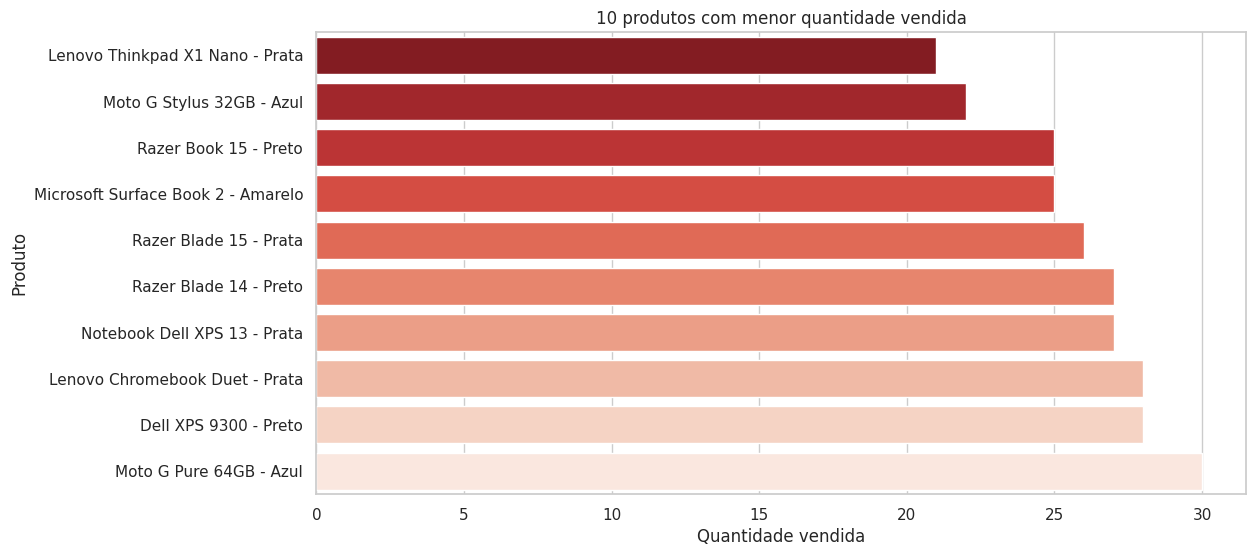

In [156]:
bottom10 = ranking_produtos.tail(10).sort_values("quantidade_vendida", ascending=True)

plt.figure(figsize=(12,6))
sns.barplot(data=bottom10, y="nome_produto", x="quantidade_vendida", palette="Reds_r")
plt.title("10 produtos com menor quantidade vendida")
plt.xlabel("Quantidade vendida")
plt.ylabel("Produto")
plt.show()

Bloco 3: análise por categoria
Se existir coluna categoria, agregue por categoria para entender concentração da demanda.
Isso ajuda a identificar categorias que merecem maior atenção no forecast e na política de reposição.

,categoria,quantidade_vendida,receita
4,Mouse,20431,"242,338.01"
6,Teclado,7838,"417,647.12"
3,Monitor,4224,"958,748.53"
1,Casaco,3800,"163,866.00"
0,Camisa,3332,"85,022.50"
2,Celular,2919,"1,145,126.00"
5,Notebook,2770,"4,046,711.31"


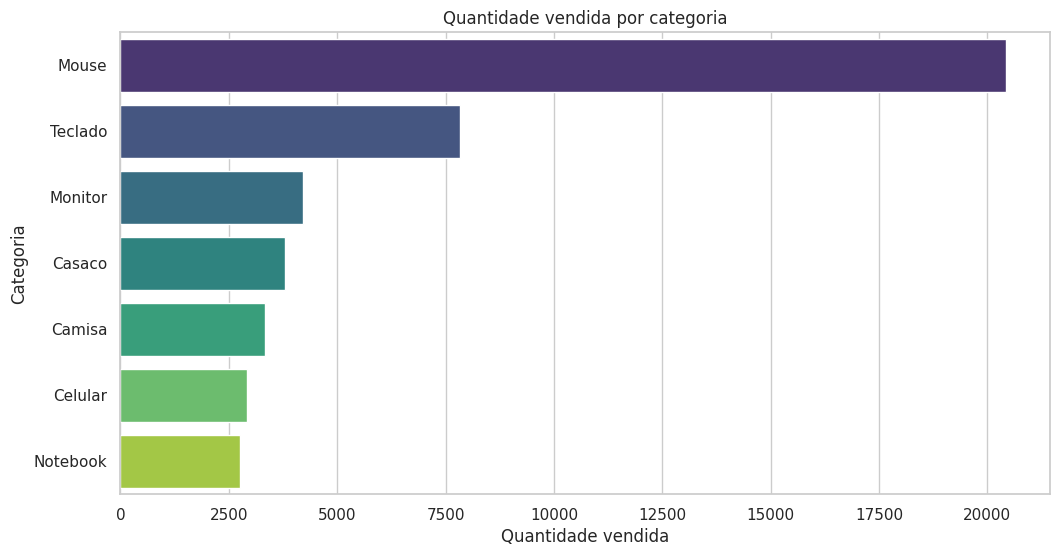

In [157]:
if "categoria" in base.columns:
    vendas_categoria = (
        base.groupby("categoria", as_index=False)
            .agg(
                quantidade_vendida=("quantidade", "sum"),
                receita=("valor_total", "sum") if "valor_total" in base.columns else ("quantidade", "sum")
            )
            .sort_values("quantidade_vendida", ascending=False)
    )

    display(vendas_categoria)

    plt.figure(figsize=(12,6))
    sns.barplot(data=vendas_categoria, x="quantidade_vendida", y="categoria", palette="viridis")
    plt.title("Quantidade vendida por categoria")
    plt.xlabel("Quantidade vendida")
    plt.ylabel("Categoria")
    plt.show()

Bloco 4: vendas por dia
Agora vamos entender os dias com maior e menor volume. �
Agregação diária

In [158]:
vendas_por_dia = (
    base.groupby("data_venda", as_index=False)
        .agg(
            quantidade_vendida=("quantidade", "sum"),
            receita=("valor_total", "sum") if "valor_total" in base.columns else ("quantidade", "sum")
        )
        .sort_values("data_venda")
)

Dias com maior e menor volume

In [159]:
display(vendas_por_dia.sort_values("quantidade_vendida", ascending=False).head(10))
display(vendas_por_dia.sort_values("quantidade_vendida", ascending=True).head(10))

,data_venda,quantidade_vendida,receita
59,2022-03-01,473,"68,765.84"
92,2022-04-03,393,"52,556.73"
50,2022-02-20,374,"44,210.45"
164,2022-06-14,367,"60,801.97"
161,2022-06-11,353,"60,033.84"
108,2022-04-19,344,"52,778.63"
157,2022-06-07,342,"60,019.37"
120,2022-05-01,335,"46,958.51"
167,2022-06-17,331,"55,183.89"
171,2022-06-21,331,"58,455.64"


,data_venda,quantidade_vendida,receita
0,2022-01-01,155,"14,070.40"
55,2022-02-25,155,"29,923.99"
74,2022-03-16,160,"34,511.53"
102,2022-04-13,167,"31,923.19"
56,2022-02-26,176,"20,272.90"
8,2022-01-09,180,"21,040.64"
60,2022-03-02,181,"28,630.71"
22,2022-01-23,183,"18,146.75"
11,2022-01-12,185,"28,901.34"
24,2022-01-25,188,"23,945.06"


Série temporal diária
Esse gráfico mostra visualmente picos, quedas e volatilidade.

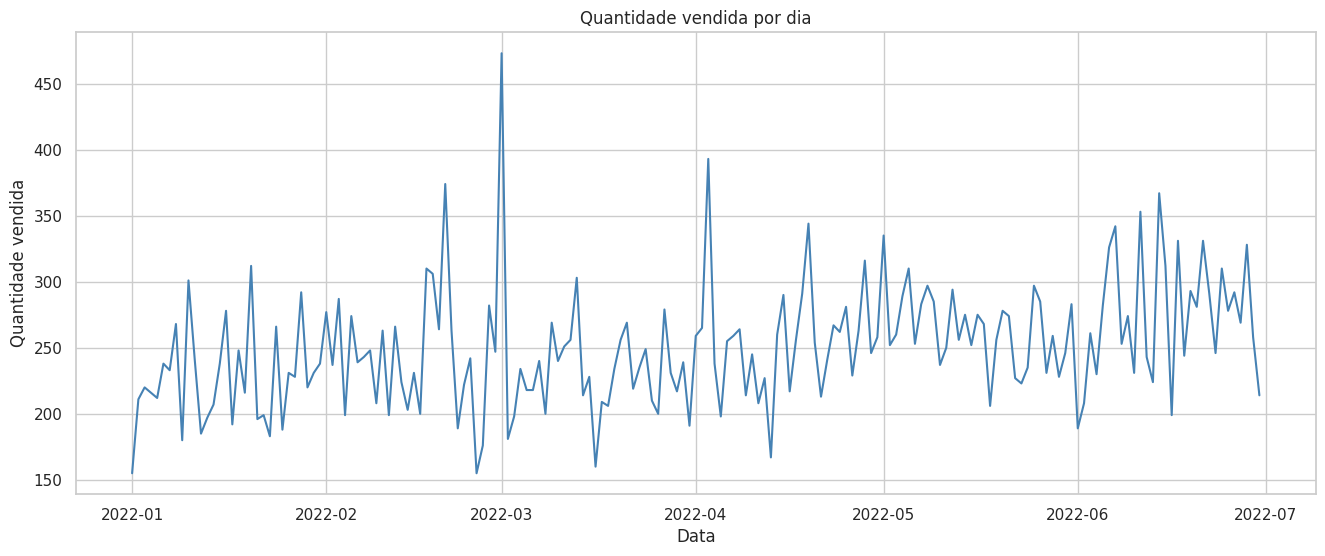

In [160]:
plt.figure(figsize=(16,6))
plt.plot(vendas_por_dia["data_venda"], vendas_por_dia["quantidade_vendida"], color="steelblue")
plt.title("Quantidade vendida por dia")
plt.xlabel("Data")
plt.ylabel("Quantidade vendida")
plt.show()

Bloco 5: tendência mensal
A agregação mensal é uma das mais importantes para enxergar sazonalidade.

In [161]:
vendas_mensais = (
    base.set_index("data_venda")
        .resample("M")
        .agg({
            "quantidade": "sum",
            "valor_total": "sum" if "valor_total" in base.columns else "sum"
        })
        .reset_index()
)

vendas_mensais = vendas_mensais.rename(columns={"quantidade": "quantidade_vendida"})
display(vendas_mensais)

,data_venda,quantidade_vendida,valor_total
0,2022-01-31,7020,"994,701.35"
1,2022-02-28,6828,"984,548.49"
2,2022-03-31,7327,"1,097,108.55"
3,2022-04-30,7680,"1,178,353.31"
4,2022-05-31,8199,"1,388,069.88"
5,2022-06-30,8260,"1,416,677.89"


Gráfico mensal

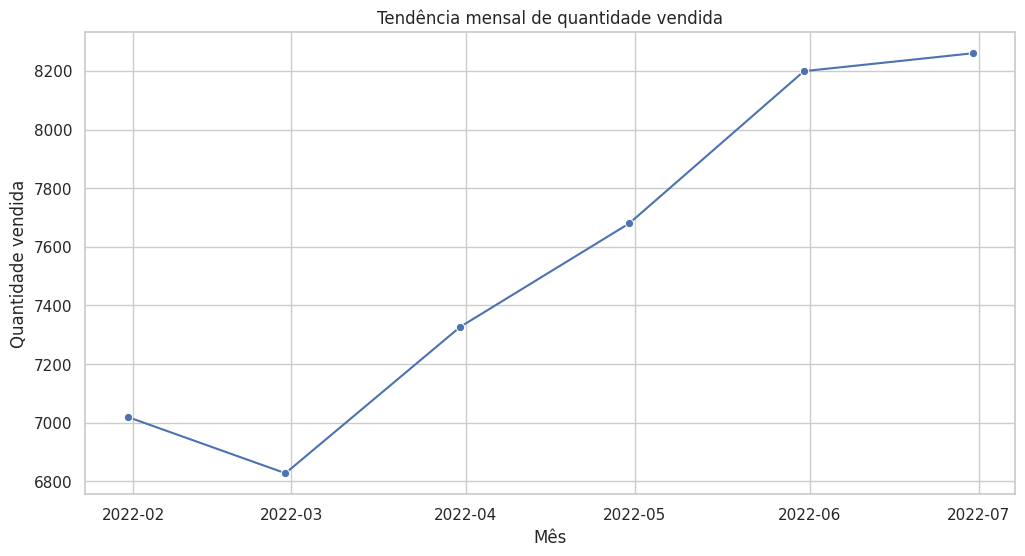

In [162]:
plt.figure(figsize=(12,6))
sns.lineplot(data=vendas_mensais, x="data_venda", y="quantidade_vendida", marker="o")
plt.title("Tendência mensal de quantidade vendida")
plt.xlabel("Mês")
plt.ylabel("Quantidade vendida")
plt.show()

Se você observar meses com crescimento recorrente ou forte variação, isso é indício de sazonalidade e tendência.

Bloco 6: análise por dia da semana
Esse bloco ajuda a identificar padrão operacional e comportamento de compra. �
Primeiro, defina uma ordem correta:

In [163]:
ordem_dias = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

Agora agregue:
Se sua base já estiver em português, adapte a lista de ordenação.

,dia_semana,quantidade_vendida,receita
1,Monday,6526,"1,019,961.93"
5,Tuesday,6824,"1,122,089.07"
6,Wednesday,6079,"969,976.35"
4,Thursday,6498,"1,018,454.03"
0,Friday,6139,"955,571.83"
2,Saturday,6385,"1,026,024.40"
3,Sunday,6863,"947,381.86"


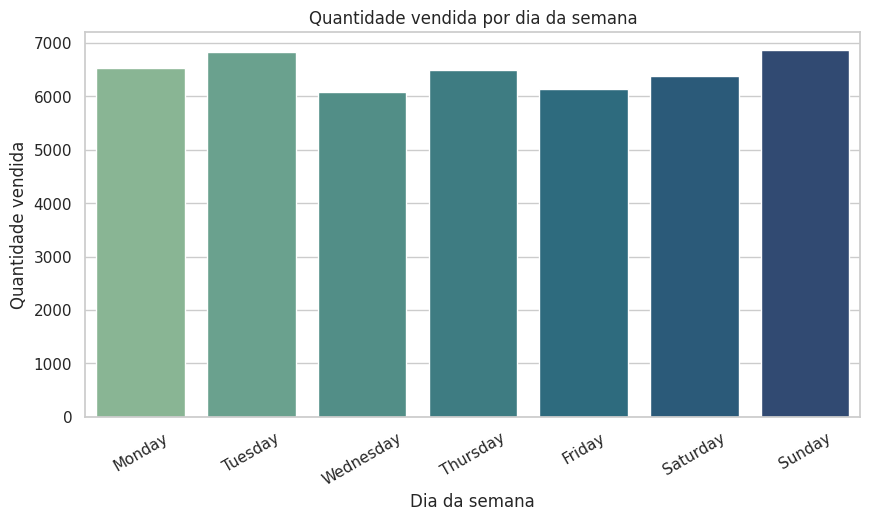

In [164]:
if "dia_semana" in base.columns:
    vendas_dia_semana = (
        base.groupby("dia_semana", as_index=False)
            .agg(
                quantidade_vendida=("quantidade", "sum"),
                receita=("valor_total", "sum") if "valor_total" in base.columns else ("quantidade", "sum")
            )
    )

    vendas_dia_semana["dia_semana"] = pd.Categorical(
        vendas_dia_semana["dia_semana"],
        categories=ordem_dias,
        ordered=True
    )

    vendas_dia_semana = vendas_dia_semana.sort_values("dia_semana")
    display(vendas_dia_semana)

    plt.figure(figsize=(10,5))
    sns.barplot(data=vendas_dia_semana, x="dia_semana", y="quantidade_vendida", palette="crest")
    plt.title("Quantidade vendida por dia da semana")
    plt.xlabel("Dia da semana")
    plt.ylabel("Quantidade vendida")
    plt.xticks(rotation=30)
    plt.show()

Bloco 7: análise por mês do ano
Esse gráfico ajuda a mostrar sazonalidade anual de forma clara.

,mes_nome,quantidade_vendida,receita
2,January,7020,"994,701.35"
1,February,6828,"984,548.49"
4,March,7327,"1,097,108.55"
0,April,7680,"1,178,353.31"
5,May,8199,"1,388,069.88"
3,June,8260,"1,416,677.89"


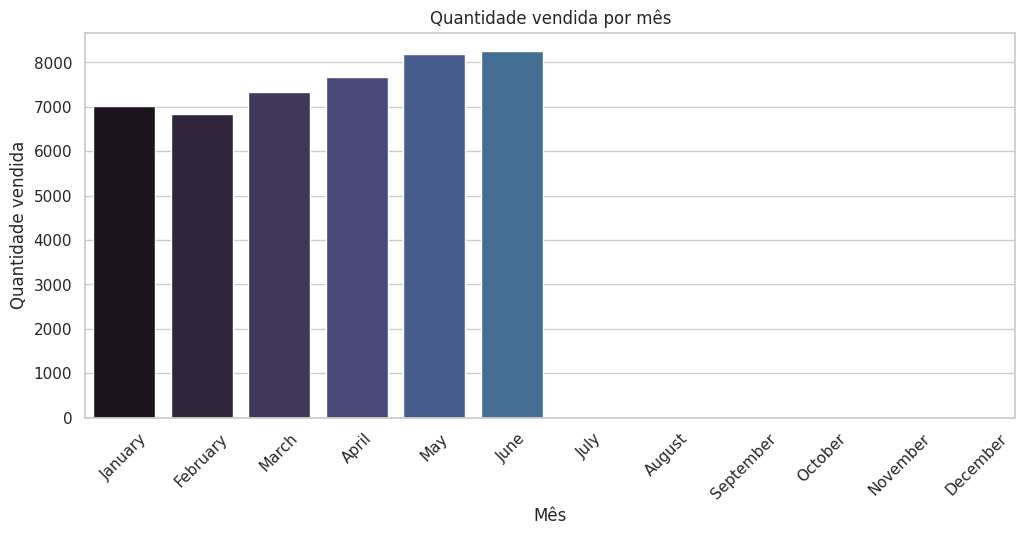

In [165]:
base["mes_num"] = base["data_venda"].dt.month
base["mes_nome"] = base["data_venda"].dt.month_name()

ordem_meses = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

vendas_por_mes = (
    base.groupby("mes_nome", as_index=False)
        .agg(
            quantidade_vendida=("quantidade", "sum"),
            receita=("valor_total", "sum") if "valor_total" in base.columns else ("quantidade", "sum")
        )
)

vendas_por_mes["mes_nome"] = pd.Categorical(
    vendas_por_mes["mes_nome"],
    categories=ordem_meses,
    ordered=True
)

vendas_por_mes = vendas_por_mes.sort_values("mes_nome")
display(vendas_por_mes)

plt.figure(figsize=(12,5))
sns.barplot(data=vendas_por_mes, x="mes_nome", y="quantidade_vendida", palette="mako")
plt.title("Quantidade vendida por mês")
plt.xlabel("Mês")
plt.ylabel("Quantidade vendida")
plt.xticks(rotation=45)
plt.show()

Meses muito acima da média indicam períodos críticos para planejamento de estoque.

Bloco 8: identificação de picos e quedas
Agora vamos localizar dias atípicos. �
Crie z-score simples para detectar picos:

In [166]:
media = vendas_por_dia["quantidade_vendida"].mean()
desvio = vendas_por_dia["quantidade_vendida"].std()

vendas_por_dia["zscore"] = (vendas_por_dia["quantidade_vendida"] - media) / desvio
picos = vendas_por_dia[vendas_por_dia["zscore"] >= 2]
quedas = vendas_por_dia[vendas_por_dia["zscore"] <= -2]

print("Picos identificados:")
display(picos)

print("Quedas identificadas:")
display(quedas)

Picos identificados:


,data_venda,quantidade_vendida,receita,zscore
50,2022-02-20,374,"44,210.45",2.69
59,2022-03-01,473,"68,765.84",4.85
92,2022-04-03,393,"52,556.73",3.10
108,2022-04-19,344,"52,778.63",2.04
161,2022-06-11,353,"60,033.84",2.23
164,2022-06-14,367,"60,801.97",2.54


Quedas identificadas:


,data_venda,quantidade_vendida,receita,zscore
0,2022-01-01,155,"14,070.40",-2.08
55,2022-02-25,155,"29,923.99",-2.08


Isso é útil para associar dias extremos a promoções, sazonalidade ou problemas operacionais

Bloco 9: impacto de promoções
Se você tiver a variável promocao_flag, compare comportamento de venda com e sem promoção

In [167]:
if "promocao_flag" in base.columns:
    impacto_promocao = (
        base.groupby("promocao_flag", as_index=False)
            .agg(
                quantidade_media=("quantidade", "mean"),
                quantidade_total=("quantidade", "sum"),
                receita_total=("valor_total", "sum") if "valor_total" in base.columns else ("quantidade", "sum")
            )
    )
    display(impacto_promocao)

,promocao_flag,quantidade_media,quantidade_total,receita_total
0,0,1.54,45314,"7,059,459.47"


Gráfico de comparação

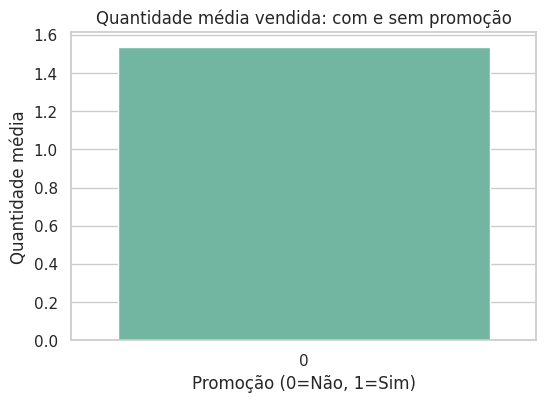

In [168]:
if "promocao_flag" in base.columns:
    plt.figure(figsize=(6,4))
    sns.barplot(data=impacto_promocao, x="promocao_flag", y="quantidade_media", palette="Set2")
    plt.title("Quantidade média vendida: com e sem promoção")
    plt.xlabel("Promoção (0=Não, 1=Sim)")
    plt.ylabel("Quantidade média")
    plt.show()

Se a média com promoção for muito maior, isso confirma que a variável promocional deve entrar no modelo de previsão

Bloco 10: heatmap de sazonalidade
Uma boa visualização para o relatório é uma matriz mês x dia da semana.

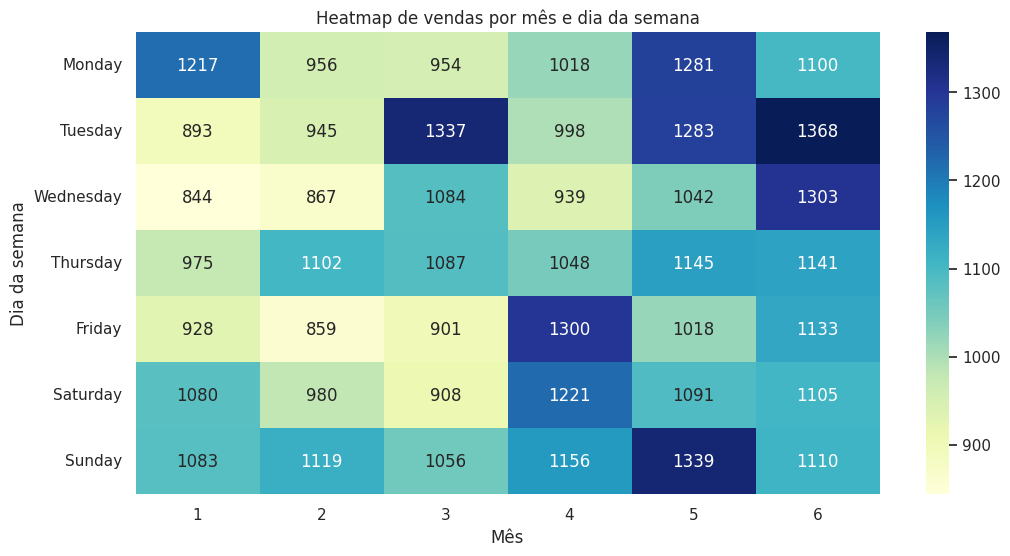

In [169]:
heat = (
    base.groupby(["mes_num", "dia_semana"], as_index=False)
        .agg(quantidade_vendida=("quantidade", "sum"))
)

heat_pivot = heat.pivot(index="dia_semana", columns="mes_num", values="quantidade_vendida")

ordem_dias_heat = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
heat_pivot = heat_pivot.reindex(ordem_dias_heat)

plt.figure(figsize=(12,6))
sns.heatmap(heat_pivot, cmap="YlGnBu", annot=True, fmt=".0f")
plt.title("Heatmap de vendas por mês e dia da semana")
plt.xlabel("Mês")
plt.ylabel("Dia da semana")
plt.show()

Isso ajuda a mostrar em quais combinações de tempo as vendas se concentram.

Bloco 11: salvar tabelas-resumo
Salve os resumos para usar depois no dashboard:

In [171]:
ranking_produtos.to_csv("eda_ranking_produtos.csv", index=False)
vendas_por_dia.to_csv("eda_vendas_por_dia.csv", index=False)
vendas_mensais.to_csv("eda_vendas_mensais.csv", index=False)
vendas_por_mes.to_csv("eda_vendas_por_mes.csv", index=False)

Se existir:

In [172]:
if "categoria" in base.columns:
    vendas_categoria.to_csv("eda_vendas_categoria.csv", index=False)

if "dia_semana" in base.columns:
    vendas_dia_semana.to_csv("eda_vendas_dia_semana.csv", index=False)

if "promocao_flag" in base.columns:
    impacto_promocao.to_csv("eda_impacto_promocao.csv", index=False)

Esses arquivos serão úteis para alimentar o Streamlit sem recalcular tudo a cada abertura. �

Insights que você deve procurar
Ao analisar os gráficos e tabelas, procure responder:
Existe concentração de vendas em poucos produtos? �
Há meses de pico que exigem aumento de estoque? �
Certos dias da semana concentram maior demanda? �
Promoções elevam de fato a quantidade vendida? �
Existem picos isolados que podem representar campanhas ou sazonalidade especial?

Na etapa de análise exploratória, foram identificados os produtos de maior e menor giro, a distribuição temporal das vendas, os períodos de pico e queda e os padrões sazonais por mês e dia da semana. As análises também permitiram avaliar o impacto de promoções sobre o volume vendido, fornecendo evidências para inclusão de variáveis sazonais e promocionais no modelo preditivo. �
O que sai pronto dessa etapa
Ao final do Pipeline 2, você terá:
ranking de produtos;
tendência diária e mensal; �
análise por categoria;
sazonalidade por mês e dia da semana; �
comparação com e sem promoção;
tabelas e gráficos prontos para relatório e dashboard.

Objetivo do Pipeline 3
Ao final desta etapa, você deve ter:
um modelo de previsão funcional; �
métricas de avaliação como MAE e MAPE; �
previsões para os próximos 3 a 6 meses; �
base final exportada para Power BI e Streamlit;
gráficos de histórico vs. previsão e componentes de sazonalidade. �
Estratégia recomendada
Como a empresa quer otimizar estoque, você pode começar com uma previsão em dois níveis:
Nível 1: previsão agregada geral, para mostrar tendência total da empresa.
Nível 2: previsão por produto ou por top produtos, para decisões operacionais de reposição. �
Se a base tiver muitos SKUs, não vale prever todos no início; prefira:
top 10 ou top 20 produtos por volume;
ou previsão por categoria.
Isso torna o projeto mais estável e explicável.

Bloco 1: instalar Prophet e importar bibliotecas

In [173]:
import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

Bloco 2: carregar os dados

In [174]:
base_diaria_geral = pd.read_csv("base_diaria_geral.csv", parse_dates=["data_venda"])
base = pd.read_csv("base_analitica.csv", parse_dates=["data_venda"])

In [176]:
df_prophet = base_diaria_geral.rename(columns={
    "data_venda": "ds",
    "quantidade_vendida": "y"
}).copy()

df_prophet = df_prophet.sort_values("ds").reset_index(drop=True)
display(df_prophet.head())

,ds,y,receita
0,2022-01-01,155,"14,070.40"
1,2022-01-02,211,"30,829.34"
2,2022-01-03,220,"24,662.41"
3,2022-01-04,216,"45,046.04"
4,2022-01-05,212,"36,860.61"


Bloco 3: inspeção da série temporal

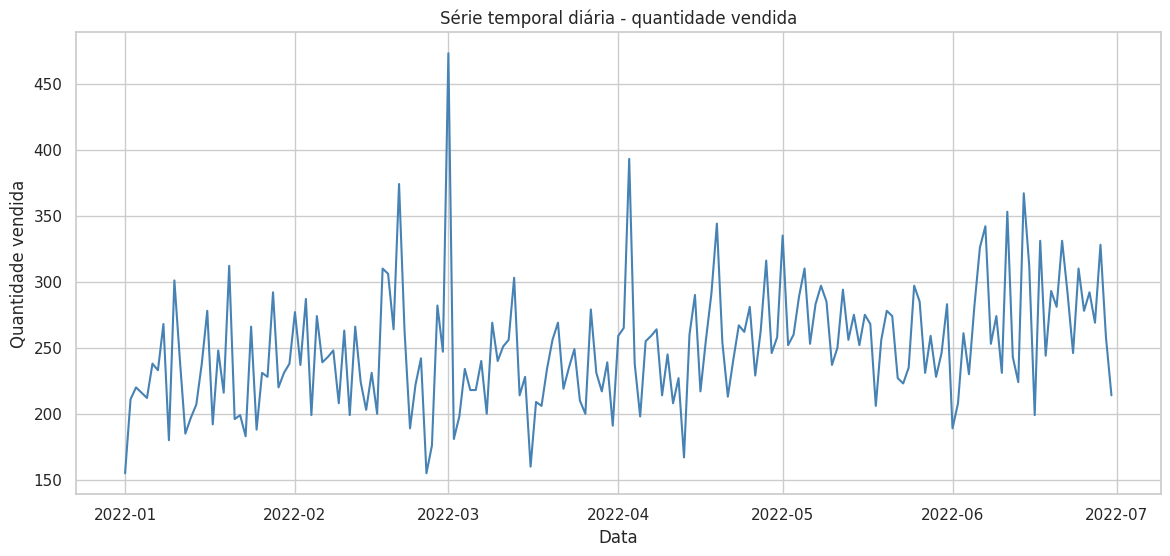

In [177]:
plt.figure(figsize=(14,6))
plt.plot(df_prophet["ds"], df_prophet["y"], color="steelblue")
plt.title("Série temporal diária - quantidade vendida")
plt.xlabel("Data")
plt.ylabel("Quantidade vendida")
plt.show()

Essa checagem ajuda a confirmar presença de tendência, volatilidade e picos.

Bloco 4: split treino e teste
Separe parte final da série para validar o modelo. Uma divisão simples é deixar os últimos 30 ou 60 dias como teste.

In [178]:
horizonte_teste = 30

train = df_prophet.iloc[:-horizonte_teste].copy()
test = df_prophet.iloc[-horizonte_teste:].copy()

print("Treino:", train.shape)
print("Teste:", test.shape)
print("Última data treino:", train["ds"].max())
print("Primeira data teste:", test["ds"].min())

Treino: (151, 3)
Teste: (30, 3)
Última data treino: 2022-05-31 00:00:00
Primeira data teste: 2022-06-01 00:00:00


Bloco 5: modelo básico com Prophet
Crie um modelo inicial com sazonalidade semanal e anual. O Prophet trabalha muito bem nesse cenário

In [179]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode="additive"
)

model.fit(train)

Depois gere previsão no horizonte do teste:

In [180]:
future_test = model.make_future_dataframe(periods=horizonte_teste, freq="D")
forecast_test = model.predict(future_test)

In [ ]:
Selecione só a parte do teste:

In [181]:
prev_test = forecast_test[["ds", "yhat", "yhat_lower", "yhat_upper"]].merge(
    test[["ds", "y"]],
    on="ds",
    how="inner"
)

display(prev_test.head())

,ds,yhat,yhat_lower,yhat_upper,y
0,2022-06-01,242.88,193.78,293.63,189
1,2022-06-02,273.33,223.10,326.03,208
2,2022-06-03,259.43,209.92,310.25,261
3,2022-06-04,266.28,214.48,314.30,230
4,2022-06-05,291.02,242.47,338.32,282


Bloco 6: avaliação do modelo
Agora calcule métricas principais. �

In [183]:

mae = mean_absolute_error(prev_test["y"], prev_test["yhat"])
mape = mean_absolute_percentage_error(prev_test["y"], prev_test["yhat"]) * 100

print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2f}%")

MAE: 45.03
MAPE: 17.95%


Interpretação:
MAE mostra o erro médio em unidades vendidas. �
MAPE mostra o erro percentual médio e facilita explicar o desempenho para o negócio.

Bloco 7: gráfico real vs previsto
Esse é um dos gráficos mais importantes do projeto.

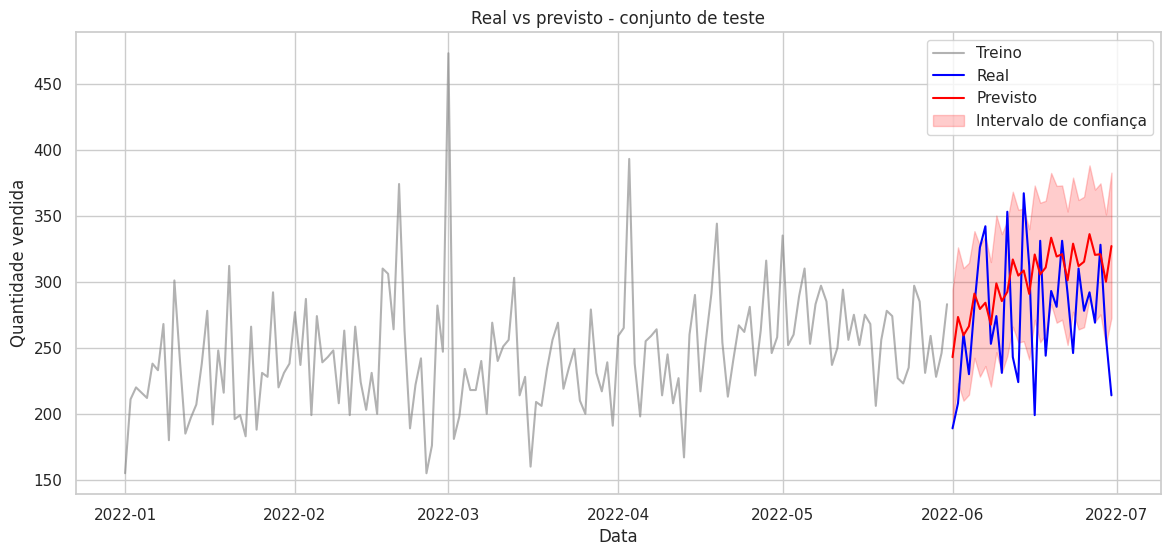

In [184]:
plt.figure(figsize=(14,6))
plt.plot(train["ds"], train["y"], label="Treino", color="gray", alpha=0.6)
plt.plot(test["ds"], test["y"], label="Real", color="blue")
plt.plot(prev_test["ds"], prev_test["yhat"], label="Previsto", color="red")
plt.fill_between(
    prev_test["ds"],
    prev_test["yhat_lower"],
    prev_test["yhat_upper"],
    color="red",
    alpha=0.2,
    label="Intervalo de confiança"
)
plt.title("Real vs previsto - conjunto de teste")
plt.xlabel("Data")
plt.ylabel("Quantidade vendida")
plt.legend()
plt.show()

Bloco 8: melhorar o modelo com promoções
Se você tiver uma variável promocional por dia, pode adicionar como regressora, o que o Prophet suporta diretamente. �
Criando base diária com promoção

In [185]:
base_diaria_full = (
    base.groupby("data_venda", as_index=False)
        .agg(
            quantidade_vendida=("quantidade", "sum"),
            promocao_flag=("promocao_flag", "max")
        )
)

df_reg = base_diaria_full.rename(columns={
    "data_venda": "ds",
    "quantidade_vendida": "y"
}).sort_values("ds")

Split

In [186]:
train_reg = df_reg.iloc[:-horizonte_teste].copy()
test_reg = df_reg.iloc[-horizonte_teste:].copy()

Modelo com regressora

In [187]:
model_reg = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode="additive"
)

model_reg.add_regressor("promocao_flag")
model_reg.fit(train_reg)

Futuro para teste

In [188]:
future_reg = test_reg[["ds", "promocao_flag"]].copy()
future_hist = train_reg[["ds", "promocao_flag"]].copy()
future_full = pd.concat([future_hist, future_reg], axis=0)

forecast_reg = model_reg.predict(future_full)

prev_test_reg = forecast_reg[["ds", "yhat", "yhat_lower", "yhat_upper"]].merge(
    test_reg[["ds", "y"]],
    on="ds",
    how="inner"
)

Métricas

In [189]:
mae_reg = mean_absolute_error(prev_test_reg["y"], prev_test_reg["yhat"])
mape_reg = mean_absolute_percentage_error(prev_test_reg["y"], prev_test_reg["yhat"]) * 100

print(f"MAE com regressora: {mae_reg:.2f}")
print(f"MAPE com regressora: {mape_reg:.2f}%")

MAE com regressora: 45.03
MAPE com regressora: 17.95%


Se o erro cair, isso indica que promoções influenciam a demanda e devem ser consideradas. �

Bloco 9: escolher o melhor modelo

In [190]:
comparacao_modelos = pd.DataFrame({
    "modelo": ["Prophet básico", "Prophet com promoção"],
    "MAE": [mae, mae_reg if 'mae_reg' in locals() else np.nan],
    "MAPE": [mape, mape_reg if 'mape_reg' in locals() else np.nan]
})

display(comparacao_modelos)

,modelo,MAE,MAPE
0,Prophet básico,45.03,17.95
1,Prophet com promoção,45.03,17.95


Escolha o modelo com menor erro e melhor interpretabilidade

Bloco 10: treinar o modelo final em toda a base
Depois de validar, treine o modelo final usando toda a série histórica. �
Sem regressora

In [191]:
modelo_final = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode="additive"
)

modelo_final.fit(df_prophet)

Horizonte futuro
Se quiser prever os próximos 90 dias

In [192]:
periodos_futuros = 90
future = modelo_final.make_future_dataframe(periods=periodos_futuros, freq="D")
forecast_final = modelo_final.predict(future)

Se usar regressora, você precisará fornecer valores futuros da regressora também. � Para um projeto acadêmico, uma estratégia simples é:
assumir promocao_flag = 0 para dias normais;
marcar manualmente datas promocionais conhecidas, se existirem.

Bloco 11: visualizar previsão futura

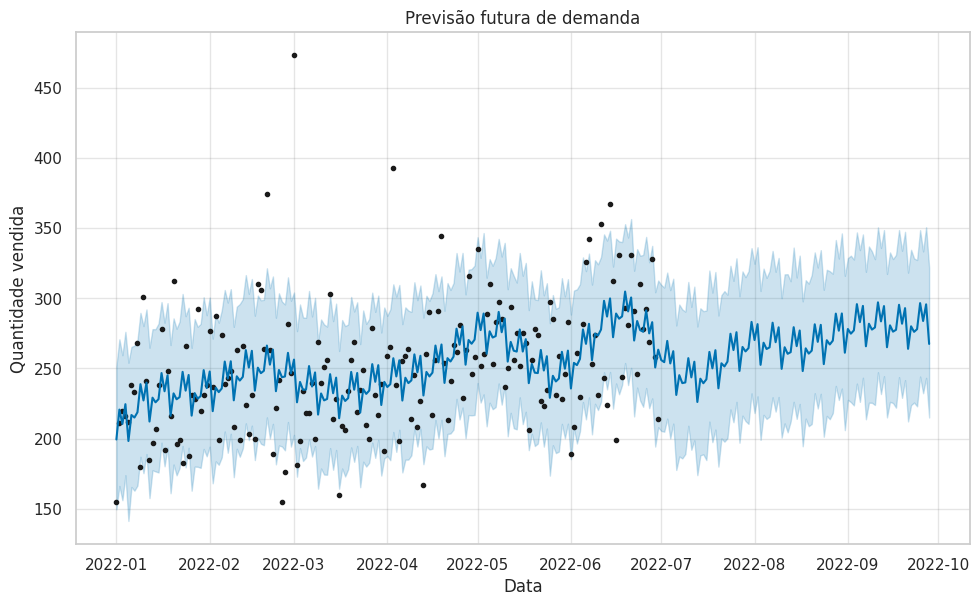

In [193]:
fig1 = modelo_final.plot(forecast_final)
plt.title("Previsão futura de demanda")
plt.xlabel("Data")
plt.ylabel("Quantidade vendida")
plt.show()

Componentes do modelo:

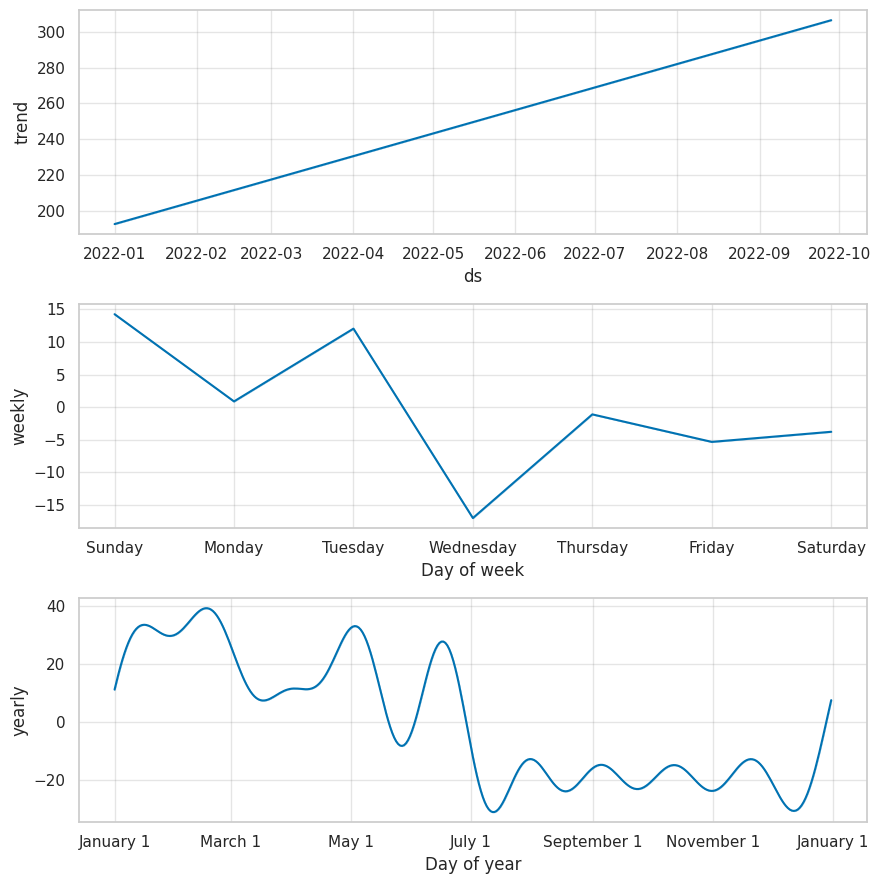

In [194]:
fig2 = modelo_final.plot_components(forecast_final)
plt.show()

Esse gráfico mostra decomposição de tendência e sazonalidade, o que é muito útil para explicar o modelo no relatório.

Bloco 12: previsão mensal para relatório
Como o desafio fala em próximos meses, agregue a previsão diária por mês:

In [195]:
forecast_mensal = forecast_final.copy()
forecast_mensal["ano_mes"] = forecast_mensal["ds"].dt.to_period("M").astype(str)

previsao_mensal = (
    forecast_mensal.groupby("ano_mes", as_index=False)
        .agg(
            demanda_prevista=("yhat", "sum"),
            limite_inferior=("yhat_lower", "sum"),
            limite_superior=("yhat_upper", "sum")
        )
)

display(previsao_mensal.tail(6))

,ano_mes,demanda_prevista,limite_inferior,limite_superior
3,2022-04,"7,604.83","6,021.13","9,172.43"
4,2022-05,"8,137.42","6,539.37","9,786.66"
5,2022-06,"8,292.96","6,731.93","9,852.46"
6,2022-07,"7,865.86","6,233.75","9,476.61"
7,2022-08,"8,334.71","6,736.57","9,951.07"
8,2022-09,"7,893.97","6,421.89","9,365.71"


Bloco 13: previsão por produto
Para estoque, o ideal é prever os produtos mais relevantes. �
Selecionar top produtos

In [196]:
top_skus = (
    base.groupby(["sku", "nome_produto"], as_index=False)
        .agg(qtd_total=("quantidade", "sum"))
        .sort_values("qtd_total", ascending=False)
        .head(10)
)

display(top_skus)

,sku,nome_produto,qtd_total
11,HL164,Mouse sem fio MO251 2.4 Ghz - Preto,4565
14,HL167,Teclado sem fio V320 - Preto,3255
27,HL215,Mouse sem fio M185 - Preto,3121
82,HL6,"Camisa Hashtag Eletro Masculina, G - Branco",2394
28,HL216,Teclado LG X130 - Branco,2379
19,HL172,Mouse com fio USB M90 - Preto,2222
12,HL165,Mouse Óptico USB 1200dpi - Preto,2190
13,HL166,Mouse M90 1000dpi - Preto,1943
29,HL217,Monitor Gamer 24'' FHD 75HZ - Branco,1572
0,HL1,M510 Mouse sem fio - Vermelho,1218


Função de previsão por SKU

In [197]:
def prever_sku(df_base, sku, periodos=30):
    temp = (
        df_base[df_base["sku"] == sku]
        .groupby("data_venda", as_index=False)
        .agg(quantidade_vendida=("quantidade", "sum"))
        .rename(columns={"data_venda": "ds", "quantidade_vendida": "y"})
        .sort_values("ds")
    )

    if len(temp) < 30:
        return None

    m = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
    m.fit(temp)

    future = m.make_future_dataframe(periods=periodos, freq="D")
    fcst = m.predict(future)[["ds", "yhat", "yhat_lower", "yhat_upper"]]
    fcst["sku"] = sku
    return fcst

Rodar para os top produtos

In [198]:
lista_forecasts = []

for sku in top_skus["sku"]:
    try:
        fcst = prever_sku(base, sku, periodos=90)
        if fcst is not None:
            lista_forecasts.append(fcst)
    except Exception as e:
        print(f"Erro no SKU {sku}: {e}")

forecast_skus = pd.concat(lista_forecasts, ignore_index=True)
display(forecast_skus.head())

,ds,yhat,yhat_lower,yhat_upper,sku
0,2022-01-01,18.77,9.42,27.78,HL164
1,2022-01-02,20.15,11.45,29.20,HL164
2,2022-01-03,19.54,10.37,29.43,HL164
3,2022-01-04,21.85,12.88,31.08,HL164
4,2022-01-05,19.24,10.45,28.44,HL164


Isso gera uma base útil para reposição por item

Bloco 14: salvar resultados
Agora exporte os arquivos principais:

In [199]:
prev_test.to_csv("forecast_validacao.csv", index=False)
forecast_final.to_csv("forecast_geral_diario.csv", index=False)
previsao_mensal.to_csv("forecast_geral_mensal.csv", index=False)
comparacao_modelos.to_csv("comparacao_modelos_forecast.csv", index=False)

Se gerou forecast por SKU:

In [200]:
forecast_skus.to_csv("forecast_skus_diario.csv", index=False)

Para prever a demanda futura, foi utilizado o modelo Prophet em Python, adequado para séries temporais com tendência e sazonalidade semanal e anual. O modelo foi treinado com o histórico de vendas diárias e avaliado com métricas como MAE e MAPE, permitindo comparar versões com e sem regressoras promocionais. �
Após a validação, foi gerada a previsão da demanda para os meses seguintes, tanto em nível agregado quanto para os principais produtos, fornecendo base quantitativa para definição de estoque de segurança, ponto de reposição e alertas operacionais. �
O que sai pronto desta etapa
Ao final do Pipeline 3, você terá:
previsão histórica validada; �
métricas de erro;
previsão futura diária e mensal; �
decomposição de tendência e sazonalidade; �
forecast por SKU para produtos prioritários.

O Pipeline 4 no Colab é a etapa em que a previsão de demanda vira decisão operacional de estoque: definir estoque de segurança, ponto de ressuprimento, cobertura em dias, risco de ruptura e excesso, além de priorizar produtos por criticidade. �
Essa parte responde diretamente ao problema da E‑ComTech, porque não basta prever vendas; é preciso transformar a previsão em uma política prática de reposição que reduza perdas por falta e por excesso. �
Objetivo do Pipeline 4
Ao final desta etapa, você terá:
cálculo de estoque de segurança; �
cálculo de ponto de ressuprimento; �
dias de cobertura de estoque; �
classificação de produtos com risco de ruptura ou excesso;
análise ABC para priorização operacional. �
Lógica de negócio que vamos usar
A estrutura recomendada é:
Estimar a demanda média por SKU.
Medir variabilidade da demanda.
Definir um lead time médio de reposição. �
Calcular estoque de segurança com base na variabilidade e no nível de serviço. �
Calcular ponto de ressuprimento:
demanda no lead time + estoque de segurança. �
Calcular dias de cobertura:
estoque atual / demanda média diária. �
Classificar itens em:
Ruptura iminente
Atenção
Normal
Excesso
Premissas
Como seu projeto é acadêmico, é normal que a base não tenha estoque atual real nem lead time real. Então você pode trabalhar com premissas documentadas, por exemplo:
lead_time_dias = 7
nivel_servico = 95%
z = 1.65 para 95% de serviço
estoque atual estimado a partir de uma coluna real, se existir; se não existir, usar uma base simulada ou informada manualmente. �
Se sua base tiver estoque atual no cadastro de produtos, use esse valor. Se não tiver, crie uma coluna auxiliar para demonstrar a metodologia.

Bloco 1: carregar dados
Vamos assumir que você já tem:
base_analitica.csv
forecast_skus_diario.csv ou forecast_geral_mensal.csv
Carregue:

In [201]:
import pandas as pd
import numpy as np

base = pd.read_csv("base_analitica.csv", parse_dates=["data_venda"])

forecast_skus = pd.read_csv("forecast_skus_diario.csv", parse_dates=["ds"])

Se você ainda não gerou forecast por SKU, pode usar a própria demanda histórica média para esta etapa, mas o ideal é usar a previsão por SKU.

Bloco 2: calcular demanda média e variabilidade por SKU
Crie uma base diária por SKU com histórico:

In [202]:
demanda_hist = (
    base.groupby(["sku", "data_venda"], as_index=False)
        .agg(
            demanda_dia=("quantidade", "sum")
        )
)

Agora calcule estatísticas por SKU:

In [203]:
demanda_stats = (
    demanda_hist.groupby("sku", as_index=False)
        .agg(
            demanda_media_diaria=("demanda_dia", "mean"),
            desvio_demanda_diaria=("demanda_dia", "std"),
            demanda_max_diaria=("demanda_dia", "max"),
            demanda_total=("demanda_dia", "sum"),
            dias_com_venda=("data_venda", "nunique")
        )
)

demanda_stats["desvio_demanda_diaria"] = demanda_stats["desvio_demanda_diaria"].fillna(0)
display(demanda_stats.head())

,sku,demanda_media_diaria,desvio_demanda_diaria,demanda_max_diaria,demanda_total,dias_com_venda
0,HL1,6.73,2.57,16,1218,181
1,HL10,1.73,0.89,5,208,120
2,HL152,3.66,1.76,9,487,133
3,HL153,3.81,2.42,12,537,141
4,HL154,3.79,2.27,14,515,136


A média e o desvio padrão são a base para calcular segurança e reposição.

Bloco 3: trazer nome do produto e categoria

In [204]:
dim_produtos = base[["sku", "nome_produto", "categoria"]].drop_duplicates()
demanda_stats = demanda_stats.merge(dim_produtos, on="sku", how="left")

Bloco 4: definir premissas operacionais
Defina os parâmetros do modelo:

In [205]:
lead_time_dias = 7
nivel_servico = 0.95
z = 1.65

Essas premissas devem ser explicadas no relatório como parâmetros de planejamento.

Bloco 5: calcular estoque de segurança
Uma fórmula comum é:
onde:
[z] = fator do nível de serviço
[\sigma_d] = desvio padrão da demanda diária
[LT] = lead time em dias
Isso é amplamente usado em planejamento de estoque.

In [206]:
demanda_stats["estoque_seguranca"] = (
    z * demanda_stats["desvio_demanda_diaria"] * np.sqrt(lead_time_dias)
).round(0)

Bloco 6: calcular ponto de ressuprimento

In [207]:
demanda_stats["ponto_ressuprimento"] = (
    (demanda_stats["demanda_media_diaria"] * lead_time_dias) +
    demanda_stats["estoque_seguranca"]
).round(0)

Bloco 7: trazer demanda prevista futura
Agora vamos usar a previsão por SKU para enriquecer a decisão. �
Se forecast_skus tiver toda a série histórica + futura, primeiro filtre apenas datas futuras:

In [208]:
ultima_data_hist = base["data_venda"].max()

forecast_futuro = forecast_skus[forecast_skus["ds"] > ultima_data_hist].copy()

Agora calcule a previsão dos próximos 30 dias por SKU:

In [209]:
demanda_30d = (
    forecast_futuro.groupby("sku", as_index=False)
        .agg(
            demanda_prevista_30d=("yhat", "sum"),
            demanda_prevista_media_dia=("yhat", "mean")
        )
)

Depois faça merge:

In [210]:
demanda_stats = demanda_stats.merge(demanda_30d, on="sku", how="left")

Se algum SKU não tiver previsão futura, preencha com a média histórica:

In [211]:
demanda_stats["demanda_prevista_media_dia"] = demanda_stats["demanda_prevista_media_dia"].fillna(
    demanda_stats["demanda_media_diaria"]
)

demanda_stats["demanda_prevista_30d"] = demanda_stats["demanda_prevista_30d"].fillna(
    demanda_stats["demanda_media_diaria"] * 30
)

Bloco 8: estoque atual
Se sua base de produtos tiver estoque atual, faça merge. Exemplo:

In [212]:
produtos = pd.read_csv("produtos_tratado.csv")

if "estoque_atual" in produtos.columns:
    estoque_atual = produtos[["sku", "estoque_atual"]].drop_duplicates()
    demanda_stats = demanda_stats.merge(estoque_atual, on="sku", how="left")

Se não existir, simule uma coluna para fins acadêmicos, deixando isso explícito no relatório:

In [213]:
if "estoque_atual" not in demanda_stats.columns:
    np.random.seed(42)
    demanda_stats["estoque_atual"] = (
        demanda_stats["demanda_media_diaria"] * np.random.randint(5, 25, size=len(demanda_stats))
    ).round(0)

Isso não é ideal para produção, mas é aceitável em projeto didático, desde que seja claramente documentado.

Bloco 9: calcular cobertura de estoque
Dias de cobertura mostram quantos dias o estoque atual consegue suportar a demanda média.

In [215]:
demanda_stats["dias_cobertura"] = np.where(
    demanda_stats["demanda_prevista_media_dia"] > 0,
    demanda_stats["estoque_atual"] / demanda_stats["demanda_prevista_media_dia"],
    np.nan
).round(1)

Esse é um KPI muito útil para dashboards operacionais.

Bloco 10: classificar risco de ruptura e excesso
Crie regras simples e objetivas:

In [216]:
def classificar_status(row):
    if row["estoque_atual"] <= row["ponto_ressuprimento"]:
        return "Ruptura Iminente"
    elif row["dias_cobertura"] < lead_time_dias:
        return "Atenção"
    elif row["estoque_atual"] > row["demanda_prevista_30d"] * 1.2:
        return "Excesso"
    else:
        return "Normal"

demanda_stats["status_estoque"] = demanda_stats.apply(classificar_status, axis=1)

Essa classificação ajuda o time de operações a agir rapidamente.

Bloco 11: sugerir quantidade de reposição

In [217]:
demanda_stats["qtd_repor"] = (
    demanda_stats["demanda_prevista_30d"] +
    demanda_stats["estoque_seguranca"] -
    demanda_stats["estoque_atual"]
).clip(lower=0).round(0)

Essa medida já é extremamente útil para uma tabela operacional no dashboard.

Bloco 12: análise ABC
A análise ABC ajuda a priorizar esforço nos itens mais relevantes, com base no princípio de Pareto. �
Calcular receita por SKU

In [218]:
abc = (
    base.groupby(["sku", "nome_produto", "categoria"], as_index=False)
        .agg(
            receita_total=("valor_total", "sum"),
            quantidade_total=("quantidade", "sum")
        )
        .sort_values("receita_total", ascending=False)
)

Percentual e acumulado

In [219]:
abc["perc_receita"] = abc["receita_total"] / abc["receita_total"].sum()
abc["perc_acumulado"] = abc["perc_receita"].cumsum()

Classificação ABC

In [220]:
def classificar_abc(x):
    if x <= 0.80:
        return "A"
    elif x <= 0.95:
        return "B"
    else:
        return "C"

abc["classe_abc"] = abc["perc_acumulado"].apply(classificar_abc)
display(abc.head(20))

,sku,nome_produto,categoria,receita_total,quantidade_total,perc_receita,perc_acumulado,classe_abc
64,HL274,Notebook Asus ROG Zephyrus Duo 15 - Prata,Notebook,"622,911.00",89,0.09,0.09,A
38,HL248,Dell Gamer G11-i1000 - Amarelo,Notebook,"565,989.00",111,0.08,0.17,A
14,HL167,Teclado sem fio V320 - Preto,Teclado,"358,050.00",3255,0.05,0.22,A
29,HL217,Monitor Gamer 24'' FHD 75HZ - Branco,Monitor,"314,384.28",1572,0.04,0.26,A
21,HL174,Monitor de jogos Nano IPS 34GN850-B 34'' - Prata,Monitor,"311,256.06",394,0.04,0.31,A
55,HL265,HP Spectre X360 - Azul,Notebook,"294,941.00",59,0.04,0.35,A
75,HL285,Razer 17 Blade Pro 4k - Preto,Notebook,"255,968.00",32,0.04,0.39,A
37,HL247,Macrbook Pro 16.2' M1 Max - Azul,Notebook,"229,455.00",45,0.03,0.42,A
84,HL73,iPhone 12 Mini 512GB - Prata,Celular,"210,552.00",248,0.03,0.45,A
99,HL93,Samsung 15.6' Galaxy Book2 Pro - Amarelo,Notebook,"182,248.65",135,0.03,0.47,A


Agora una isso à base de estoque:

In [221]:
demanda_stats = demanda_stats.merge(
    abc[["sku", "classe_abc", "receita_total"]],
    on="sku",
    how="left"
)

Itens classe A merecem maior rigor de monitoramento e reposição.

Bloco 13: criar prioridade operacional
Combine risco + ABC:

In [222]:
def prioridade_operacional(row):
    if row["classe_abc"] == "A" and row["status_estoque"] == "Ruptura Iminente":
        return "Crítica"
    elif row["classe_abc"] == "A" and row["status_estoque"] in ["Atenção", "Excesso"]:
        return "Alta"
    elif row["classe_abc"] == "B" and row["status_estoque"] == "Ruptura Iminente":
        return "Alta"
    elif row["status_estoque"] == "Normal":
        return "Baixa"
    else:
        return "Média"

demanda_stats["prioridade_operacional"] = demanda_stats.apply(prioridade_operacional, axis=1)

Isso é muito bom para o dashboard, porque transforma análise em ação.

Bloco 14: visualizar alertas principais
Top itens críticos

In [223]:
alertas = demanda_stats.sort_values(
    ["prioridade_operacional", "qtd_repor", "receita_total"],
    ascending=[True, False, False]
)

display(alertas.head(20))

,sku,demanda_media_diaria,desvio_demanda_diaria,demanda_max_diaria,demanda_total,dias_com_venda,nome_produto,categoria,estoque_seguranca,ponto_ressuprimento,demanda_prevista_30d,demanda_prevista_media_dia,estoque_atual,dias_cobertura,status_estoque,qtd_repor,classe_abc,receita_total,prioridade_operacional
11,HL164,25.22,7.50,48,4565,181,Mouse sem fio MO251 2.4 Ghz - Preto,Mouse,33.00,210.00,"2,581.75",28.69,177.00,6.20,Ruptura Iminente,"2,438.00",B,"22,779.35",Alta
27,HL215,17.24,6.60,36,3121,181,Mouse sem fio M185 - Preto,Mouse,29.00,150.00,"1,687.03",18.74,121.00,6.50,Ruptura Iminente,"1,595.00",B,"49,904.79",Alta
58,HL268,1.57,0.85,5,152,97,Moto E7 64GB - Amarelo,Celular,4.00,15.00,47.01,1.57,9.00,5.70,Ruptura Iminente,42.00,B,"22,800.00",Alta
52,HL262,1.37,0.63,4,104,76,Positivo Motion Q464C - Azul,Notebook,3.00,13.00,41.05,1.37,8.00,5.80,Ruptura Iminente,36.00,B,"36,296.00",Alta
100,HL94,1.39,0.66,4,117,84,HP Pavilion 15.6' - Amarelo,Notebook,3.00,13.00,41.79,1.39,10.00,7.20,Ruptura Iminente,35.00,B,"42,003.00",Alta
60,HL270,1.44,0.72,4,150,104,Moto G7 64GB - Amarelo,Celular,3.00,13.00,43.27,1.44,12.00,8.30,Ruptura Iminente,34.00,B,"17,850.00",Alta
45,HL255,1.19,0.40,2,37,31,Microsoft Surface Laptop Go - Amarelo,Notebook,2.00,10.00,35.81,1.19,8.00,6.70,Ruptura Iminente,30.00,B,"36,963.00",Alta
51,HL261,1.16,0.40,3,88,76,Compaq Presario - Azul,Notebook,2.00,10.00,34.74,1.16,9.00,7.80,Ruptura Iminente,28.00,B,"33,440.00",Alta
14,HL167,17.98,6.53,38,3255,181,Teclado sem fio V320 - Preto,Teclado,28.00,154.00,"2,140.19",23.78,180.00,7.60,Normal,"1,988.00",A,"358,050.00",Baixa
28,HL216,13.14,5.27,34,2379,181,Teclado LG X130 - Branco,Teclado,23.00,115.00,"1,022.50",11.36,118.00,10.40,Normal,928.00,B,"23,790.00",Baixa


Distribuição por status

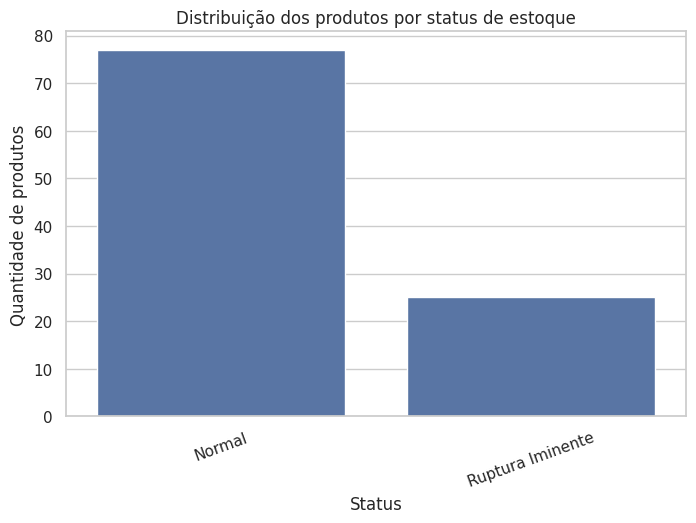

In [224]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(data=demanda_stats, x="status_estoque", order=demanda_stats["status_estoque"].value_counts().index)
plt.title("Distribuição dos produtos por status de estoque")
plt.xlabel("Status")
plt.ylabel("Quantidade de produtos")
plt.xticks(rotation=20)
plt.show()

Cobertura por classe ABC

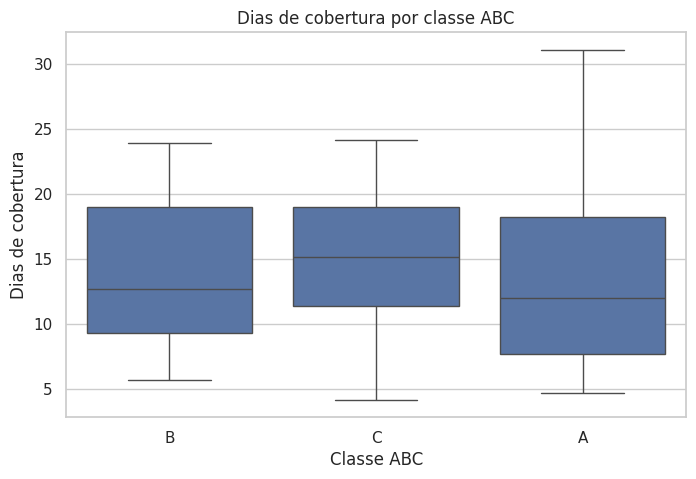

In [225]:
plt.figure(figsize=(8,5))
sns.boxplot(data=demanda_stats, x="classe_abc", y="dias_cobertura")
plt.title("Dias de cobertura por classe ABC")
plt.xlabel("Classe ABC")
plt.ylabel("Dias de cobertura")
plt.show()

Bloco 15: exportar a tabela final operacional
Essa será uma das tabelas mais importantes para o Streamlit e Power BI.

In [226]:
f_estoque = demanda_stats[[
    "sku",
    "nome_produto",
    "categoria",
    "classe_abc",
    "demanda_media_diaria",
    "desvio_demanda_diaria",
    "demanda_prevista_media_dia",
    "demanda_prevista_30d",
    "estoque_atual",
    "estoque_seguranca",
    "ponto_ressuprimento",
    "dias_cobertura",
    "status_estoque",
    "qtd_repor",
    "prioridade_operacional",
    "receita_total"
]].copy()

f_estoque.to_csv("f_estoque.csv", index=False)
display(f_estoque.head())

,sku,nome_produto,categoria,classe_abc,demanda_media_diaria,desvio_demanda_diaria,demanda_prevista_media_dia,demanda_prevista_30d,estoque_atual,estoque_seguranca,ponto_ressuprimento,dias_cobertura,status_estoque,qtd_repor,prioridade_operacional,receita_total
0,HL1,M510 Mouse sem fio - Vermelho,Mouse,B,6.73,2.57,3.51,316.22,74.00,11.00,58.00,21.10,Normal,253.00,Baixa,"31,607.10"
1,HL10,"Camisa Hashtag Eletro Masculina, G - Preto",Camisa,C,1.73,0.89,1.73,52.00,42.00,4.00,16.00,24.20,Normal,14.00,Baixa,"5,720.00"
2,HL152,"Casaco Hashtag Eletro Masculino, P - Branco",Casaco,B,3.66,1.76,3.66,109.85,70.00,8.00,34.00,19.10,Normal,48.00,Baixa,"22,353.30"
3,HL153,"Casaco Hashtag Eletro Masculino, M - Branco",Casaco,B,3.81,2.42,3.81,114.26,57.00,11.00,38.00,15.00,Normal,68.00,Baixa,"24,648.30"
4,HL154,"Casaco Hashtag Eletro Masculino, G - Branco",Casaco,B,3.79,2.27,3.79,113.60,45.00,10.00,37.00,11.90,Normal,79.00,Baixa,"23,638.50"


Após a geração das previsões de demanda, foi desenvolvida uma etapa de otimização de estoque baseada em indicadores operacionais. Foram calculados estoque de segurança, ponto de ressuprimento, dias de cobertura e quantidade sugerida de reposição, utilizando a variabilidade histórica da demanda, o lead time assumido e a previsão futura por SKU. �
Também foi aplicada a classificação ABC para priorizar os produtos mais relevantes em termos de receita, permitindo concentrar o monitoramento dos riscos de ruptura e excesso nos itens mais críticos para o negócio. �
O que sai pronto desta etapa
Ao final do Pipeline 4, você terá:
tabela operacional de estoque por SKU;
indicadores de reposição; �
classificação de risco;
análise ABC; �
base pronta para dashboards e recomendações de negócio.

O Pipeline 5 no Colab é a etapa de consolidação da camada analítica, em que você organiza e exporta os datasets finais que serão consumidos no Power BI e no dashboard em Streamlit. �
A melhor prática aqui é deixar os cálculos pesados prontos no Colab e entregar para o dashboard arquivos menores, limpos e orientados ao consumo, o que melhora desempenho, manutenção e reuso. �
Objetivo do Pipeline 5
Ao final dessa etapa, você terá uma camada de dados curada, com tabelas separadas por finalidade:
tabelas fato para vendas, previsão e estoque;
tabelas dimensão para produtos e calendário;
tabelas resumidas para KPIs, rankings e sazonalidade;
arquivos finais em CSV prontos para Power BI e Streamlit. �
Essa organização ajuda porque dashboards funcionam melhor quando consomem datasets prontos, em vez de recalcular transformações complexas toda vez que carregam.

Estrutura final recomendada
Você deve organizar sua saída analítica em dois grupos:
1. Camada para BI
Arquivos usados pelo Power BI:
f_vendas.csv
f_forecast.csv
f_estoque.csv
d_produtos.csv
d_calendario.csv
2. Camada para dashboard analítico
Arquivos usados pelo Streamlit:
kpi_resumo.csv
ranking_produtos.csv
vendas_mensais.csv
vendas_dia_semana.csv
impacto_promocao.csv
forecast_mensal.csv
alertas_estoque.csv
Essa separação entre fatos, dimensões e tabelas resumidas é muito útil para visualização e performance.

Bloco 1: carregar arquivos já gerados
Comece carregando os datasets das etapas anteriores:

In [227]:
import pandas as pd
import numpy as np

base = pd.read_csv("base_analitica.csv", parse_dates=["data_venda"])
produtos = pd.read_csv("produtos_tratado.csv")
forecast_geral_mensal = pd.read_csv("forecast_geral_mensal.csv")
forecast_skus = pd.read_csv("forecast_skus_diario.csv", parse_dates=["ds"])
f_estoque = pd.read_csv("f_estoque.csv")

Se você tiver criado tabelas do EDA separadamente, também pode carregar:

In [228]:
ranking_produtos = pd.read_csv("eda_ranking_produtos.csv")
vendas_por_dia = pd.read_csv("eda_vendas_por_dia.csv", parse_dates=["data_venda"])
vendas_mensais = pd.read_csv("eda_vendas_mensais.csv", parse_dates=["data_venda"])

Bloco 2: criar f_vendas
A fato de vendas deve ter granularidade por transação ou por dia/SKU. Para Power BI e dashboard, a melhor opção aqui é dia + SKU, porque reduz volume e ainda permite análise temporal.

In [229]:
f_vendas = (
    base.groupby(["data_venda", "sku"], as_index=False)
        .agg(
            quantidade_vendida=("quantidade", "sum"),
            receita=("valor_total", "sum"),
            promocao_flag=("promocao_flag", "max") if "promocao_flag" in base.columns else ("quantidade", "size")
        )
)

Traga atributos de produto:

In [230]:
dim_produtos_aux = base[["sku", "nome_produto", "categoria"]].drop_duplicates()
f_vendas = f_vendas.merge(dim_produtos_aux, on="sku", how="left")

Reorganize colunas:

In [231]:
f_vendas = f_vendas[[
    "data_venda",
    "sku",
    "nome_produto",
    "categoria",
    "quantidade_vendida",
    "receita",
    "promocao_flag"
]]

Bloco 3: criar d_produtos
A dimensão de produtos deve ser simples e limpa:

In [232]:
colunas_produto = [c for c in [
    "sku", "nome_produto", "categoria", "subcategoria", "marca", "preco", "custo", "fornecedor"
] if c in produtos.columns]

d_produtos = produtos[colunas_produto].drop_duplicates().copy()
display(d_produtos.head())

,sku,nome_produto,categoria,marca
0,HL1,M510 Mouse sem fio - Vermelho,Mouse,Logitech
1,HL2,Mouse sem fio M170 - Preto,Mouse,Logitech
2,HL3,"Camisa Hashtag Eletro Masculina, P - Branco",Camisa,Hashtag
3,HL4,"Camisa Hashtag Eletro Masculina, M - Branco",Camisa,Hashtag
4,HL5,Mouse sem fio D09 - Azul,Mouse,Multilaser


Se nome_produto ou categoria não estiverem em produtos, pegue da base principal:

In [234]:
if "nome_produto" not in d_produtos.columns or "categoria" not in d_produtos.columns:
    complemento = base[["sku", "nome_produto", "categoria"]].drop_duplicates()
    d_produtos = d_produtos.merge(complemento, on="sku", how="left")
    d_produtos = d_produtos.drop_duplicates()

Bloco 4: criar d_calendario
A dimensão calendário é essencial para análises temporais no Power BI.

In [235]:
data_min = base["data_venda"].min()
data_max = max(base["data_venda"].max(), forecast_skus["ds"].max() if "forecast_skus" in locals() else base["data_venda"].max())

d_calendario = pd.DataFrame({
    "data": pd.date_range(start=data_min, end=data_max, freq="D")
})

d_calendario["ano"] = d_calendario["data"].dt.year
d_calendario["mes"] = d_calendario["data"].dt.month
d_calendario["nome_mes"] = d_calendario["data"].dt.month_name()
d_calendario["ano_mes"] = d_calendario["data"].dt.to_period("M").astype(str)
d_calendario["trimestre"] = d_calendario["data"].dt.quarter
d_calendario["dia"] = d_calendario["data"].dt.day
d_calendario["dia_semana"] = d_calendario["data"].dt.day_name()
d_calendario["fim_de_semana"] = (d_calendario["data"].dt.weekday >= 5).astype(int)

display(d_calendario.head())

,data,ano,mes,nome_mes,ano_mes,trimestre,dia,dia_semana,fim_de_semana
0,2022-01-01,2022,1,January,2022-01,1,1,Saturday,1
1,2022-01-02,2022,1,January,2022-01,1,2,Sunday,1
2,2022-01-03,2022,1,January,2022-01,1,3,Monday,0
3,2022-01-04,2022,1,January,2022-01,1,4,Tuesday,0
4,2022-01-05,2022,1,January,2022-01,1,5,Wednesday,0


Bloco 5: criar f_forecast
Se você gerou previsão por SKU em base diária, padronize essa saída.

In [236]:
f_forecast = forecast_skus.rename(columns={
    "ds": "data",
    "yhat": "demanda_prevista",
    "yhat_lower": "limite_inferior",
    "yhat_upper": "limite_superior"
}).copy()

Traga atributos do produto:

In [237]:
f_forecast = f_forecast.merge(
    d_produtos[["sku"] + [c for c in ["nome_produto", "categoria"] if c in d_produtos.columns]],
    on="sku",
    how="left"
)

Reorganize:

In [238]:
cols_forecast = [c for c in [
    "data", "sku", "nome_produto", "categoria",
    "demanda_prevista", "limite_inferior", "limite_superior"
] if c in f_forecast.columns]

f_forecast = f_forecast[cols_forecast]
display(f_forecast.head())

,data,sku,nome_produto,categoria,demanda_prevista,limite_inferior,limite_superior
0,2022-01-01,HL164,Mouse sem fio MO251 2.4 Ghz - Preto,Mouse,18.77,9.42,27.78
1,2022-01-02,HL164,Mouse sem fio MO251 2.4 Ghz - Preto,Mouse,20.15,11.45,29.20
2,2022-01-03,HL164,Mouse sem fio MO251 2.4 Ghz - Preto,Mouse,19.54,10.37,29.43
3,2022-01-04,HL164,Mouse sem fio MO251 2.4 Ghz - Preto,Mouse,21.85,12.88,31.08
4,2022-01-05,HL164,Mouse sem fio MO251 2.4 Ghz - Preto,Mouse,19.24,10.45,28.44


Bloco 6: ajustar f_estoque
A tabela de estoque já veio pronta do Pipeline 4, mas agora vamos preparar a versão final para consumo.

In [239]:
alertas_estoque = f_estoque.copy()

Selecione e padronize:

In [240]:
colunas_estoque = [c for c in [
    "sku",
    "nome_produto",
    "categoria",
    "classe_abc",
    "demanda_media_diaria",
    "demanda_prevista_media_dia",
    "demanda_prevista_30d",
    "estoque_atual",
    "estoque_seguranca",
    "ponto_ressuprimento",
    "dias_cobertura",
    "status_estoque",
    "qtd_repor",
    "prioridade_operacional",
    "receita_total"
] if c in alertas_estoque.columns]

f_estoque_final = alertas_estoque[colunas_estoque].copy()
display(f_estoque_final.head())

,sku,nome_produto,categoria,classe_abc,demanda_media_diaria,demanda_prevista_media_dia,demanda_prevista_30d,estoque_atual,estoque_seguranca,ponto_ressuprimento,dias_cobertura,status_estoque,qtd_repor,prioridade_operacional,receita_total
0,HL1,M510 Mouse sem fio - Vermelho,Mouse,B,6.73,3.51,316.22,74.00,11.00,58.00,21.10,Normal,253.00,Baixa,"31,607.10"
1,HL10,"Camisa Hashtag Eletro Masculina, G - Preto",Camisa,C,1.73,1.73,52.00,42.00,4.00,16.00,24.20,Normal,14.00,Baixa,"5,720.00"
2,HL152,"Casaco Hashtag Eletro Masculino, P - Branco",Casaco,B,3.66,3.66,109.85,70.00,8.00,34.00,19.10,Normal,48.00,Baixa,"22,353.30"
3,HL153,"Casaco Hashtag Eletro Masculino, M - Branco",Casaco,B,3.81,3.81,114.26,57.00,11.00,38.00,15.00,Normal,68.00,Baixa,"24,648.30"
4,HL154,"Casaco Hashtag Eletro Masculino, G - Branco",Casaco,B,3.79,3.79,113.60,45.00,10.00,37.00,11.90,Normal,79.00,Baixa,"23,638.50"


Bloco 7: criar tabelas de resumo para dashboard
Essas tabelas ajudam o Streamlit a abrir rápido, porque os indicadores já estarão prontos. �
KPI resumo

In [241]:
kpi_resumo = pd.DataFrame({
    "kpi": [
        "Receita Total",
        "Quantidade Vendida",
        "Produtos Unicos",
        "Categorias Unicas",
        "Estoque em Risco",
        "Estoque em Excesso"
    ],
    "valor": [
        base["valor_total"].sum(),
        base["quantidade"].sum(),
        base["sku"].nunique(),
        base["categoria"].nunique() if "categoria" in base.columns else np.nan,
        (f_estoque_final["status_estoque"] == "Ruptura Iminente").sum() if "status_estoque" in f_estoque_final.columns else np.nan,
        (f_estoque_final["status_estoque"] == "Excesso").sum() if "status_estoque" in f_estoque_final.columns else np.nan
    ]
})
display(kpi_resumo)

,kpi,valor
0,Receita Total,"7,059,459.47"
1,Quantidade Vendida,"45,314.00"
2,Produtos Unicos,102.00
3,Categorias Unicas,7.00
4,Estoque em Risco,25.00
5,Estoque em Excesso,0.00


Ranking de produtos

In [242]:
ranking_produtos = (
    base.groupby(["sku", "nome_produto"], as_index=False)
        .agg(
            quantidade_vendida=("quantidade", "sum"),
            receita=("valor_total", "sum")
        )
        .sort_values("quantidade_vendida", ascending=False)
)

Vendas mensais

In [246]:
vendas_mensais = (
    base.groupby(base["data_venda"].dt.to_period("M"))
        .agg(
            quantidade_vendida=("quantidade", "sum"),
            receita=("valor_total", "sum")
        )
        .reset_index()
)

vendas_mensais["ano_mes"] = vendas_mensais["data_venda"].astype(str)
vendas_mensais = vendas_mensais.drop(columns=["data_venda"])
display(vendas_mensais.head())

,quantidade_vendida,receita,ano_mes
0,7020,"994,701.35",2022-01
1,6828,"984,548.49",2022-02
2,7327,"1,097,108.55",2022-03
3,7680,"1,178,353.31",2022-04
4,8199,"1,388,069.88",2022-05


Vendas por dia da semana

In [247]:
vendas_dia_semana = (
    base.groupby("dia_semana", as_index=False)
        .agg(
            quantidade_vendida=("quantidade", "sum"),
            receita=("valor_total", "sum")
        )
)

Impacto de promoção

In [248]:
if "promocao_flag" in base.columns:
    impacto_promocao = (
        base.groupby("promocao_flag", as_index=False)
            .agg(
                quantidade_media=("quantidade", "mean"),
                quantidade_total=("quantidade", "sum"),
                receita_total=("valor_total", "sum")
            )
    )
else:
    impacto_promocao = pd.DataFrame()

Forecast mensal
Se a previsão mensal já existir:

In [249]:
forecast_mensal = forecast_geral_mensal.copy()

Se quiser gerar a partir do forecast diário:

In [250]:
if "ano_mes" not in forecast_mensal.columns and "data" in f_forecast.columns:
    temp = f_forecast.copy()
    temp["ano_mes"] = pd.to_datetime(temp["data"]).dt.to_period("M").astype(str)
    forecast_mensal = (
        temp.groupby("ano_mes", as_index=False)
            .agg(
                demanda_prevista=("demanda_prevista", "sum"),
                limite_inferior=("limite_inferior", "sum"),
                limite_superior=("limite_superior", "sum")
            )
    )

Bloco 8: opcionalmente gerar Parquet
Se você quiser melhor desempenho no Streamlit, além de CSV, pode salvar em Parquet, que é mais leve e rápido para leitura.

In [251]:
f_vendas.to_parquet("f_vendas.parquet", index=False)
f_forecast.to_parquet("f_forecast.parquet", index=False)
f_estoque_final.to_parquet("f_estoque.parquet", index=False)

Bloco 9: exportar todos os datasets finais
Agora salve os arquivos finais:

In [252]:
f_vendas.to_csv("f_vendas.csv", index=False)
d_produtos.to_csv("d_produtos.csv", index=False)
d_calendario.to_csv("d_calendario.csv", index=False)
f_forecast.to_csv("f_forecast.csv", index=False)
f_estoque_final.to_csv("f_estoque.csv", index=False)

kpi_resumo.to_csv("kpi_resumo.csv", index=False)
ranking_produtos.to_csv("ranking_produtos.csv", index=False)
vendas_mensais.to_csv("vendas_mensais.csv", index=False)
vendas_dia_semana.to_csv("vendas_dia_semana.csv", index=False)
forecast_mensal.to_csv("forecast_mensal.csv", index=False)

if not impacto_promocao.empty:
    impacto_promocao.to_csv("impacto_promocao.csv", index=False)

alertas_estoque.to_csv("alertas_estoque.csv", index=False)

Bloco 10: validar a camada final
Faça uma checagem rápida:

In [253]:
arquivos_finais = {
    "f_vendas": f_vendas.shape,
    "d_produtos": d_produtos.shape,
    "d_calendario": d_calendario.shape,
    "f_forecast": f_forecast.shape,
    "f_estoque": f_estoque_final.shape,
    "kpi_resumo": kpi_resumo.shape,
    "ranking_produtos": ranking_produtos.shape,
    "vendas_mensais": vendas_mensais.shape,
    "vendas_dia_semana": vendas_dia_semana.shape,
    "forecast_mensal": forecast_mensal.shape
}

for nome, shape in arquivos_finais.items():
    print(nome, shape)

f_vendas (10006, 7)
d_produtos (293, 4)
d_calendario (271, 9)
f_forecast (2707, 7)
f_estoque (102, 15)
kpi_resumo (6, 2)
ranking_produtos (102, 4)
vendas_mensais (6, 3)
vendas_dia_semana (7, 3)
forecast_mensal (9, 4)


Verifique também:

In [254]:
display(f_vendas.head())
display(f_forecast.head())
display(f_estoque_final.head())

,data_venda,sku,nome_produto,categoria,quantidade_vendida,receita,promocao_flag
0,2022-01-01,HL1,M510 Mouse sem fio - Vermelho,Mouse,4,103.80,0
1,2022-01-01,HL158,"Casaco Hashtag Eletro Masculino, G - Preto",Casaco,1,48.90,0
2,2022-01-01,HL162,"Casaco Hashtag Eletro Feminino, G - Branco",Casaco,1,45.90,0
3,2022-01-01,HL164,Mouse sem fio MO251 2.4 Ghz - Preto,Mouse,25,124.75,0
4,2022-01-01,HL165,Mouse Óptico USB 1200dpi - Preto,Mouse,10,39.90,0


,data,sku,nome_produto,categoria,demanda_prevista,limite_inferior,limite_superior
0,2022-01-01,HL164,Mouse sem fio MO251 2.4 Ghz - Preto,Mouse,18.77,9.42,27.78
1,2022-01-02,HL164,Mouse sem fio MO251 2.4 Ghz - Preto,Mouse,20.15,11.45,29.20
2,2022-01-03,HL164,Mouse sem fio MO251 2.4 Ghz - Preto,Mouse,19.54,10.37,29.43
3,2022-01-04,HL164,Mouse sem fio MO251 2.4 Ghz - Preto,Mouse,21.85,12.88,31.08
4,2022-01-05,HL164,Mouse sem fio MO251 2.4 Ghz - Preto,Mouse,19.24,10.45,28.44


,sku,nome_produto,categoria,classe_abc,demanda_media_diaria,demanda_prevista_media_dia,demanda_prevista_30d,estoque_atual,estoque_seguranca,ponto_ressuprimento,dias_cobertura,status_estoque,qtd_repor,prioridade_operacional,receita_total
0,HL1,M510 Mouse sem fio - Vermelho,Mouse,B,6.73,3.51,316.22,74.00,11.00,58.00,21.10,Normal,253.00,Baixa,"31,607.10"
1,HL10,"Camisa Hashtag Eletro Masculina, G - Preto",Camisa,C,1.73,1.73,52.00,42.00,4.00,16.00,24.20,Normal,14.00,Baixa,"5,720.00"
2,HL152,"Casaco Hashtag Eletro Masculino, P - Branco",Casaco,B,3.66,3.66,109.85,70.00,8.00,34.00,19.10,Normal,48.00,Baixa,"22,353.30"
3,HL153,"Casaco Hashtag Eletro Masculino, M - Branco",Casaco,B,3.81,3.81,114.26,57.00,11.00,38.00,15.00,Normal,68.00,Baixa,"24,648.30"
4,HL154,"Casaco Hashtag Eletro Masculino, G - Branco",Casaco,B,3.79,3.79,113.60,45.00,10.00,37.00,11.90,Normal,79.00,Baixa,"23,638.50"


Como usar no Power BI
No Power BI, importe:
f_vendas.csv
d_produtos.csv
d_calendario.csv
f_forecast.csv
f_estoque.csv
Esses são os datasets centrais do modelo. �
Como usar no Streamlit
No Streamlit, use:
kpi_resumo.csv
ranking_produtos.csv
vendas_mensais.csv
vendas_dia_semana.csv
forecast_mensal.csv
impacto_promocao.csv
alertas_estoque.csv
e, se quiser drill-down, também f_vendas.csv e f_forecast.csv.

Na etapa final da camada analítica, os resultados dos pipelines anteriores foram consolidados em datasets curados voltados ao consumo por ferramentas de Business Intelligence e dashboards interativos. Foram organizadas tabelas fato de vendas, previsão e estoque, além de dimensões de produtos e calendário e tabelas-resumo para KPIs, rankings, sazonalidade e alertas operacionais. �
Essa organização permite desacoplar o processamento analítico da camada de visualização, melhorando o desempenho do Power BI e do Streamlit e facilitando a manutenção do projeto. �
O que sai pronto desta etapa
Ao final do Pipeline 5, você terá:
camada analítica completa;
arquivos finais para Power BI;
arquivos resumidos para Streamlit; �
estrutura de dados pronta para dashboards executivos e analíticos.